# Import Basic Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Matplolib default parameters
from matplotlib import rcParams
plt.style.use('default')
plt.rcParams['axes.prop_cycle'] = plt.rcParamsDefault['axes.prop_cycle']

# import warning
import warnings
warnings.filterwarnings('ignore')

# Set option max columns display
pd.set_option('max_columns', 150)

# Dataset Overview

In [ ]:
df_train = pd.read_csv("/content/train.csv")
df_test = pd.read_csv("/content/test.csv")
df_train.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [ ]:
df_test.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,61


In [ ]:
print('Shape Train Dataset', df_train.shape)
print('Shape Test Dataset', df_test.shape)

Shape Train Dataset (54808, 13)
Shape Test Dataset (23490, 12)


In [ ]:
print('Data Train Missing Values (Percent): ')
df_train.isnull().sum()/len(df_train)*100

Data Train Missing Values (Percent): 


,0
employee_id,0.000000
department,0.000000
region,0.000000
education,4.395344
gender,0.000000
recruitment_channel,0.000000
no_of_trainings,0.000000
age,0.000000
previous_year_rating,7.524449
length_of_service,0.000000


In [ ]:
print('Data Test Missing Values (Percent): ')
df_test.isnull().sum()/len(df_test)*100

Data Test Missing Values (Percent): 


,0
employee_id,0.000000
department,0.000000
region,0.000000
education,4.401873
gender,0.000000
recruitment_channel,0.000000
no_of_trainings,0.000000
age,0.000000
previous_year_rating,7.713921
length_of_service,0.000000


In [ ]:
# we will drop all missing values in test dataset, we avoid missing values imputation in test dataset
df_test = df_test.dropna()
df_test.isnull().sum()

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


In [ ]:
print('Test Dataset Duplicated values Checking')
df_test.duplicated().sum()

Test Dataset Duplicated values Checking


np.int64(0)

# Exploratory Data Analysis

In [ ]:
eda = df_train.copy()

In [ ]:
cat = eda.select_dtypes(include='object').columns
num = eda.select_dtypes(include='number').columns

## Descriptive Statistic

### Describe Statistic

In [ ]:
eda.describe().T

,count,mean,std,min,25%,50%,75%,max
employee_id,54808.0,39195.830627,22586.581449,1.0,19669.75,39225.5,58730.5,78298.0
no_of_trainings,54808.0,1.253011,0.609264,1.0,1.00,1.0,1.0,10.0
age,54808.0,34.803915,7.660169,20.0,29.00,33.0,39.0,60.0
previous_year_rating,50684.0,3.329256,1.259993,1.0,3.00,3.0,4.0,5.0
length_of_service,54808.0,5.865512,4.265094,1.0,3.00,5.0,7.0,37.0
awards_won?,54808.0,0.023172,0.150450,0.0,0.00,0.0,0.0,1.0
avg_training_score,54808.0,63.386750,13.371559,39.0,51.00,60.0,76.0,99.0
is_promoted,54808.0,0.085170,0.279137,0.0,0.00,0.0,0.0,1.0


### Num of Unique Values and Value Counts

In [ ]:
for i in eda.columns:
    if i in cat:
        print(i)
        print(eda[i].value_counts())
        print('\n')
    else:
        print(i)
        print(eda[i].nunique())
        print('\n')

employee_id
54808


department
department
Sales & Marketing    16840
Operations           11348
Technology            7138
Procurement           7138
Analytics             5352
Finance               2536
HR                    2418
Legal                 1039
R&D                    999
Name: count, dtype: int64


region
region
region_2     12343
region_22     6428
region_7      4843
region_15     2808
region_13     2648
region_26     2260
region_31     1935
region_4      1703
region_27     1659
region_16     1465
region_28     1318
region_11     1315
region_23     1175
region_29      994
region_32      945
region_19      874
region_20      850
region_14      827
region_25      819
region_17      796
region_5       766
region_6       690
region_30      657
region_8       655
region_10      648
region_1       610
region_24      508
region_12      500
region_9       420
region_21      411
region_3       346
region_34      292
region_33      269
region_18       31
Name: count, dtype: int64



## Univariate Analysis

In [ ]:
len(num)

8

### Boxplot

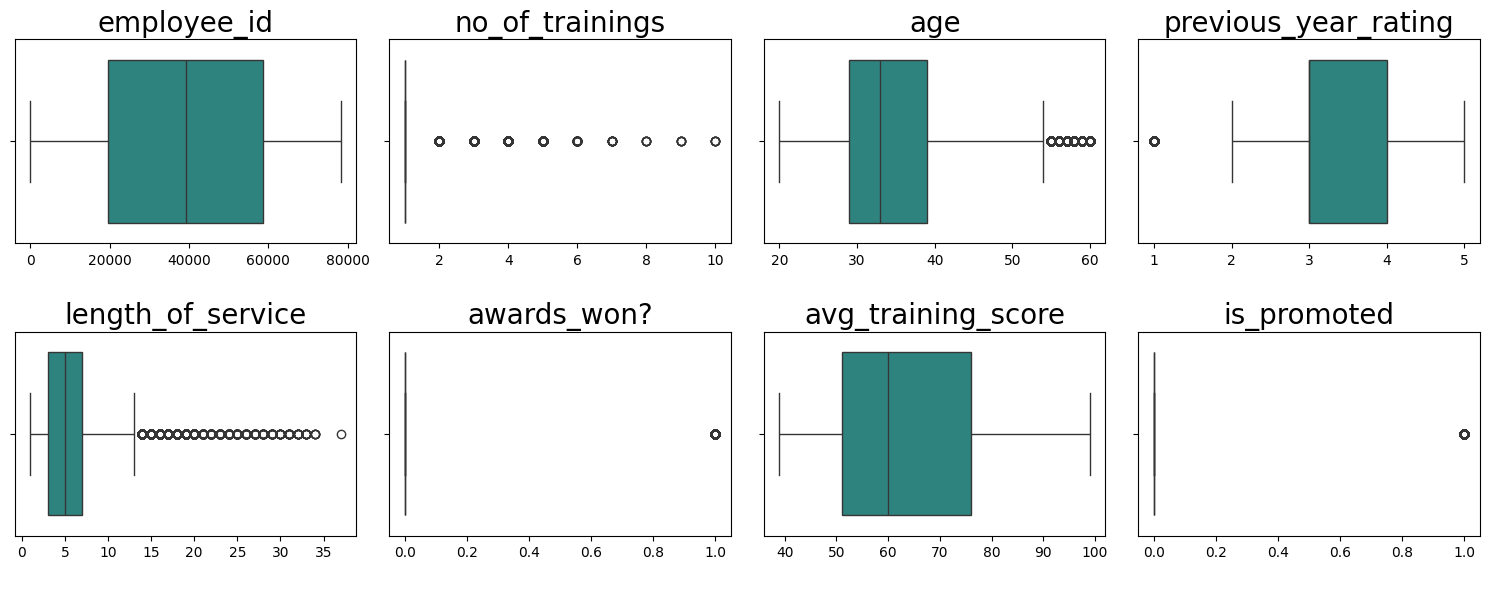

In [ ]:
plt.figure(figsize=(15,6))
for i in range(0, len(num)):
    plt.subplot(2,4,i+1)
    sns.boxplot(x=eda[num[i]], palette='viridis')
    plt.title(num[i], fontsize=20)
    plt.xlabel(' ')
    plt.tight_layout()

### Displot

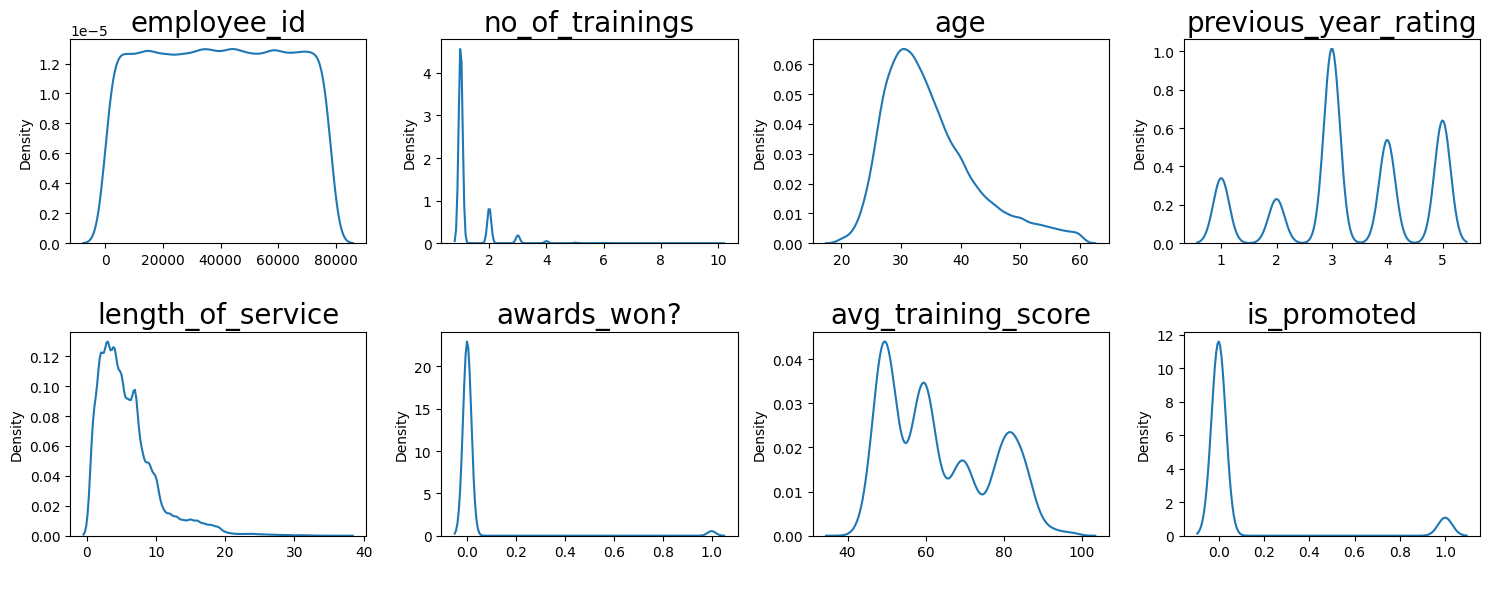

In [ ]:
plt.figure(figsize=(15,6))
for i in range(0, len(num)):
    plt.subplot(2,4,i+1)
    sns.kdeplot(x=eda[num[i]], palette='viridis')
    plt.title(num[i], fontsize=20)
    plt.xlabel(' ')
    plt.tight_layout()

### Violinplot

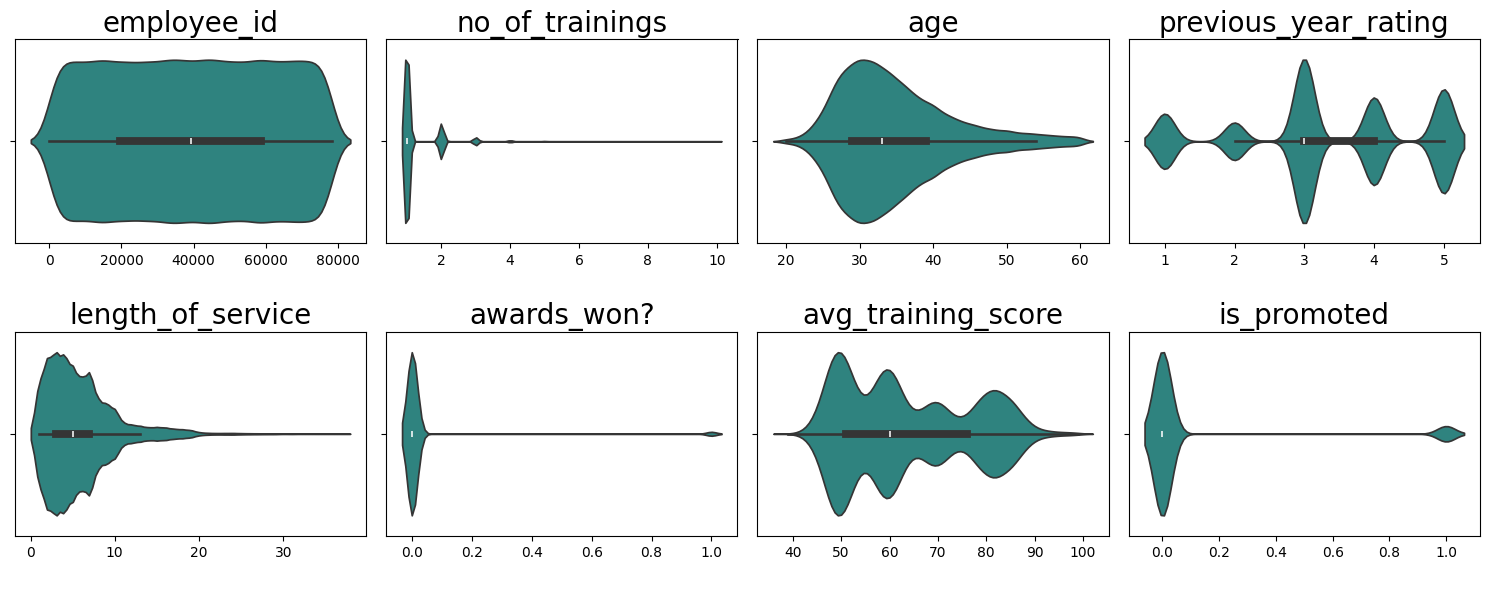

In [ ]:
plt.figure(figsize=(15,6))
for i in range(0, len(num)):
    plt.subplot(2,4,i+1)
    sns.violinplot(x=eda[num[i]], palette='viridis')
    plt.title(num[i], fontsize=20)
    plt.xlabel(' ')
    plt.tight_layout()

## Bivariate Analysis

### Numeric Feature Analysis

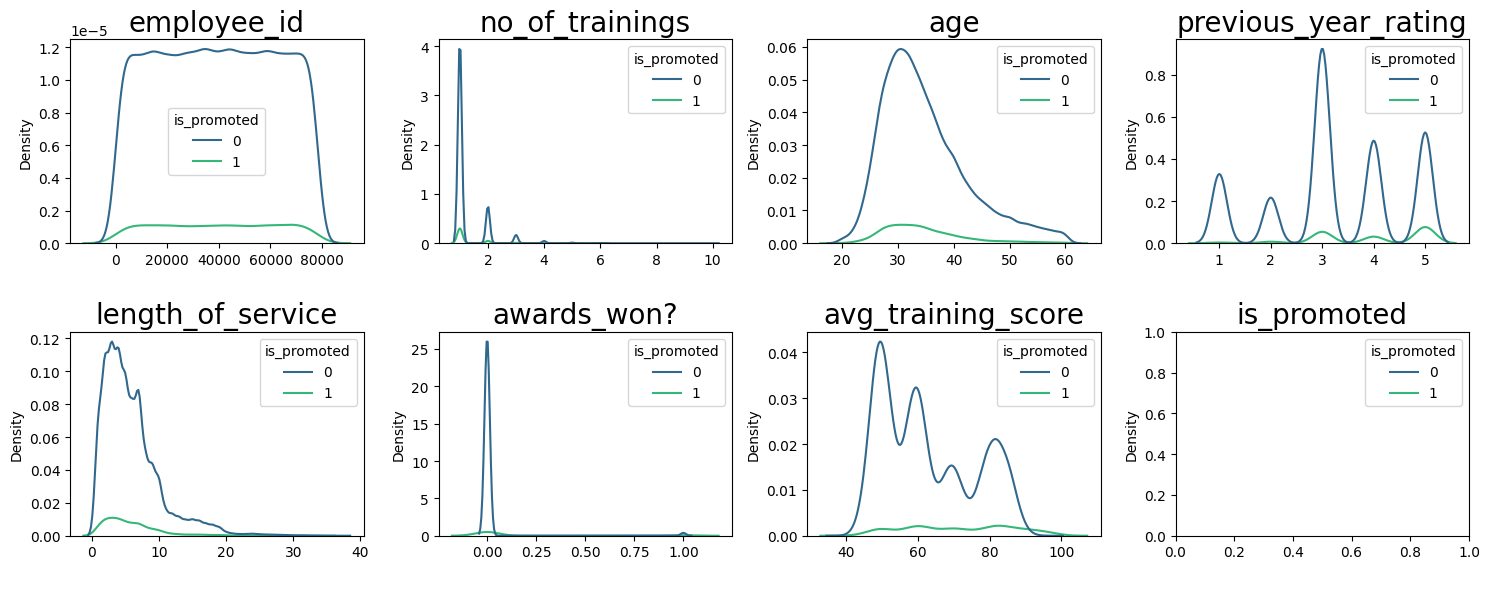

In [ ]:
plt.figure(figsize=(15,6))
for i in range(0, len(num)):
    plt.subplot(2,4,i+1)
    sns.kdeplot(x=eda[num[i]], palette='viridis', hue=eda['is_promoted'])
    plt.title(num[i], fontsize=20)
    plt.xlabel(' ')
    plt.tight_layout()

### Category Feature Analysis

In [ ]:
eda[cat].head()

,department,region,education,gender,recruitment_channel
0,Sales & Marketing,region_7,Master's & above,f,sourcing
1,Operations,region_22,Bachelor's,m,other
2,Sales & Marketing,region_19,Bachelor's,m,sourcing
3,Sales & Marketing,region_23,Bachelor's,m,other
4,Technology,region_26,Bachelor's,m,other


In [ ]:
len(cat)

5

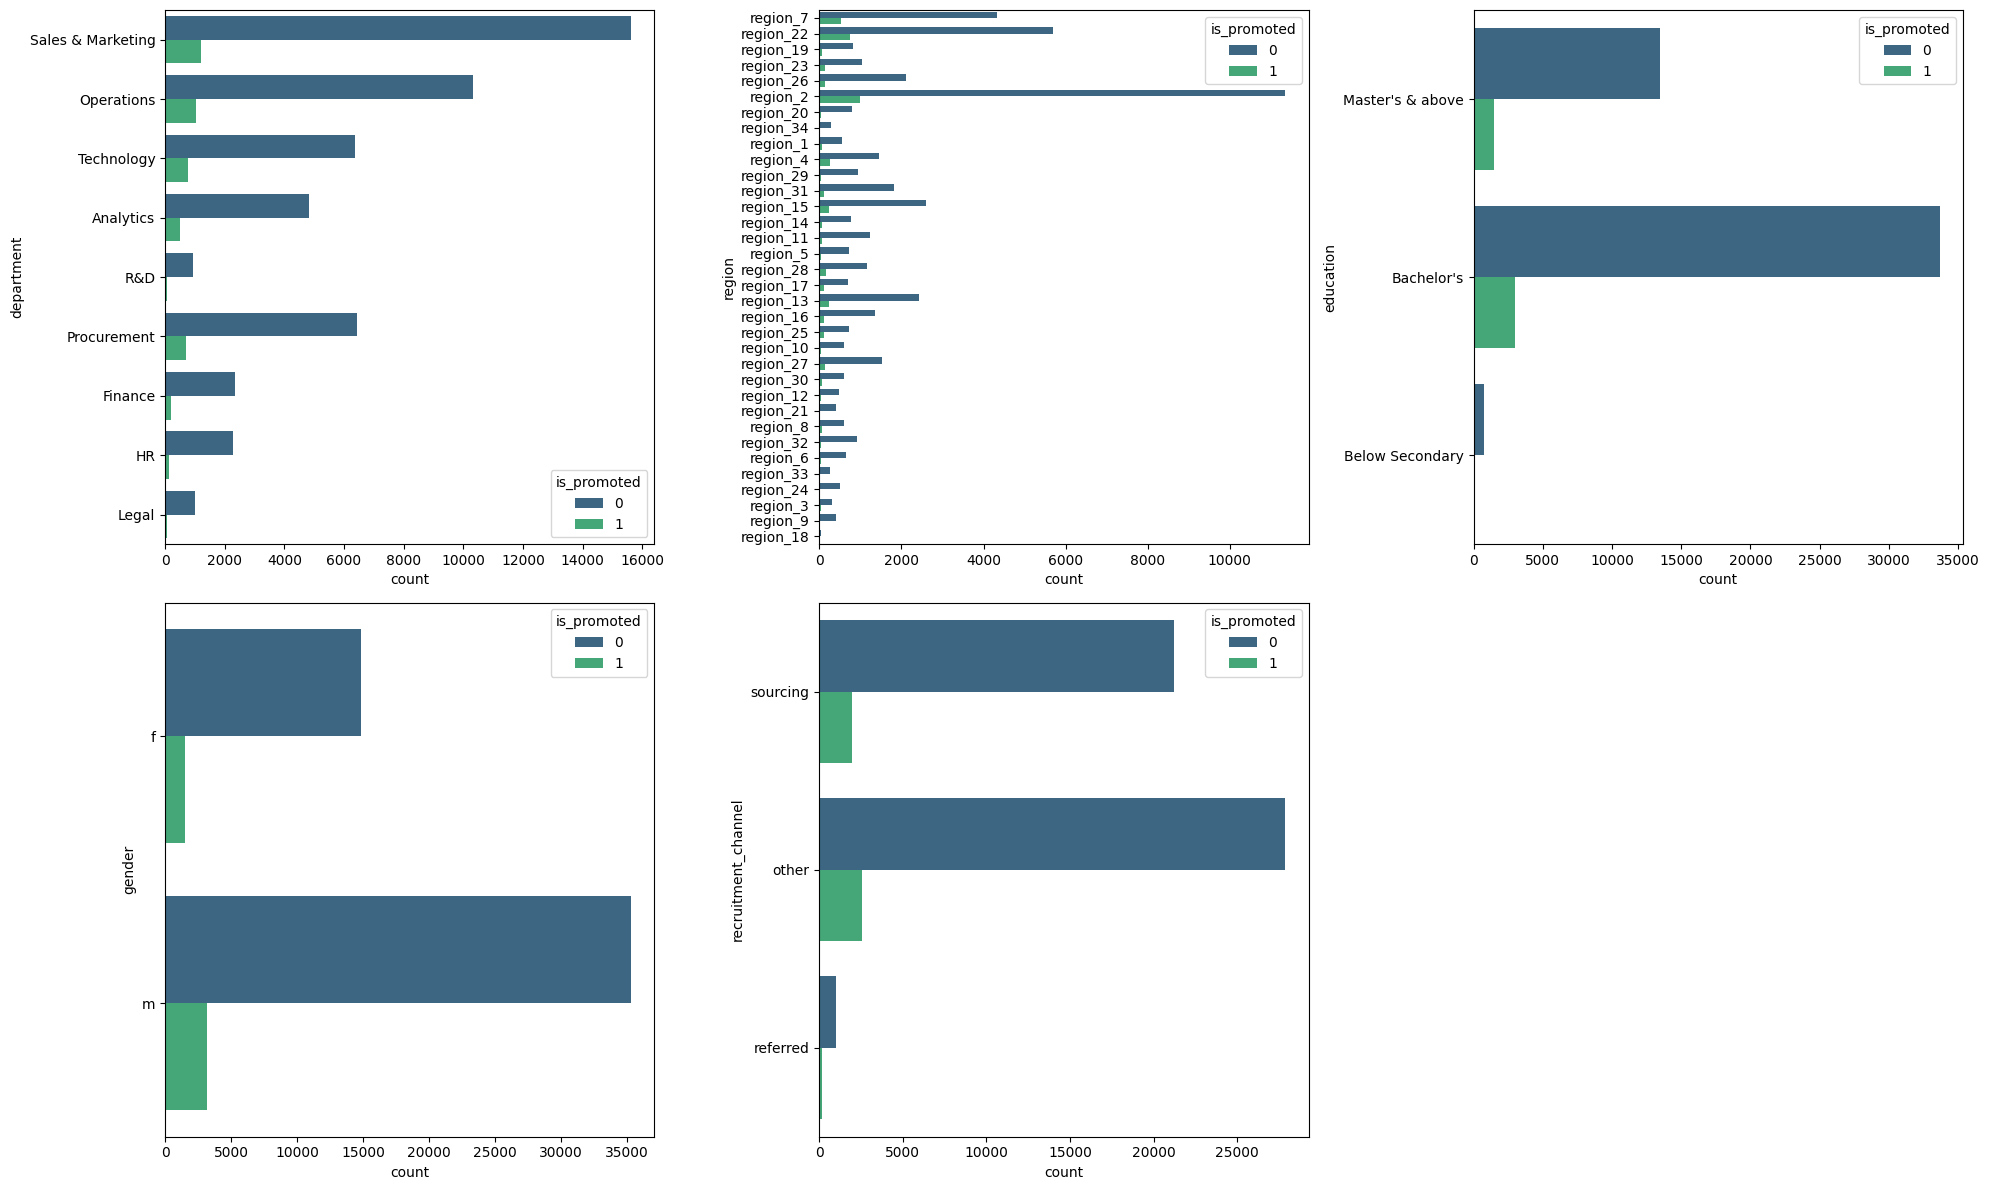

In [ ]:
fig, axes = plt.subplots(2,3, figsize=(20,12))
xy = [(0,0), (0,1), (0,2), (1,0), (1,1), (1,2)]

for i in range(len(cat)):
    sns.countplot(y=eda[cat[i]], palette='viridis', ax=axes[xy[i]], hue=eda['is_promoted'])
    plt.tight_layout()
axes[1,2].axis('off')
plt.tight_layout()

### Correlation Heatmap

<Axes: >

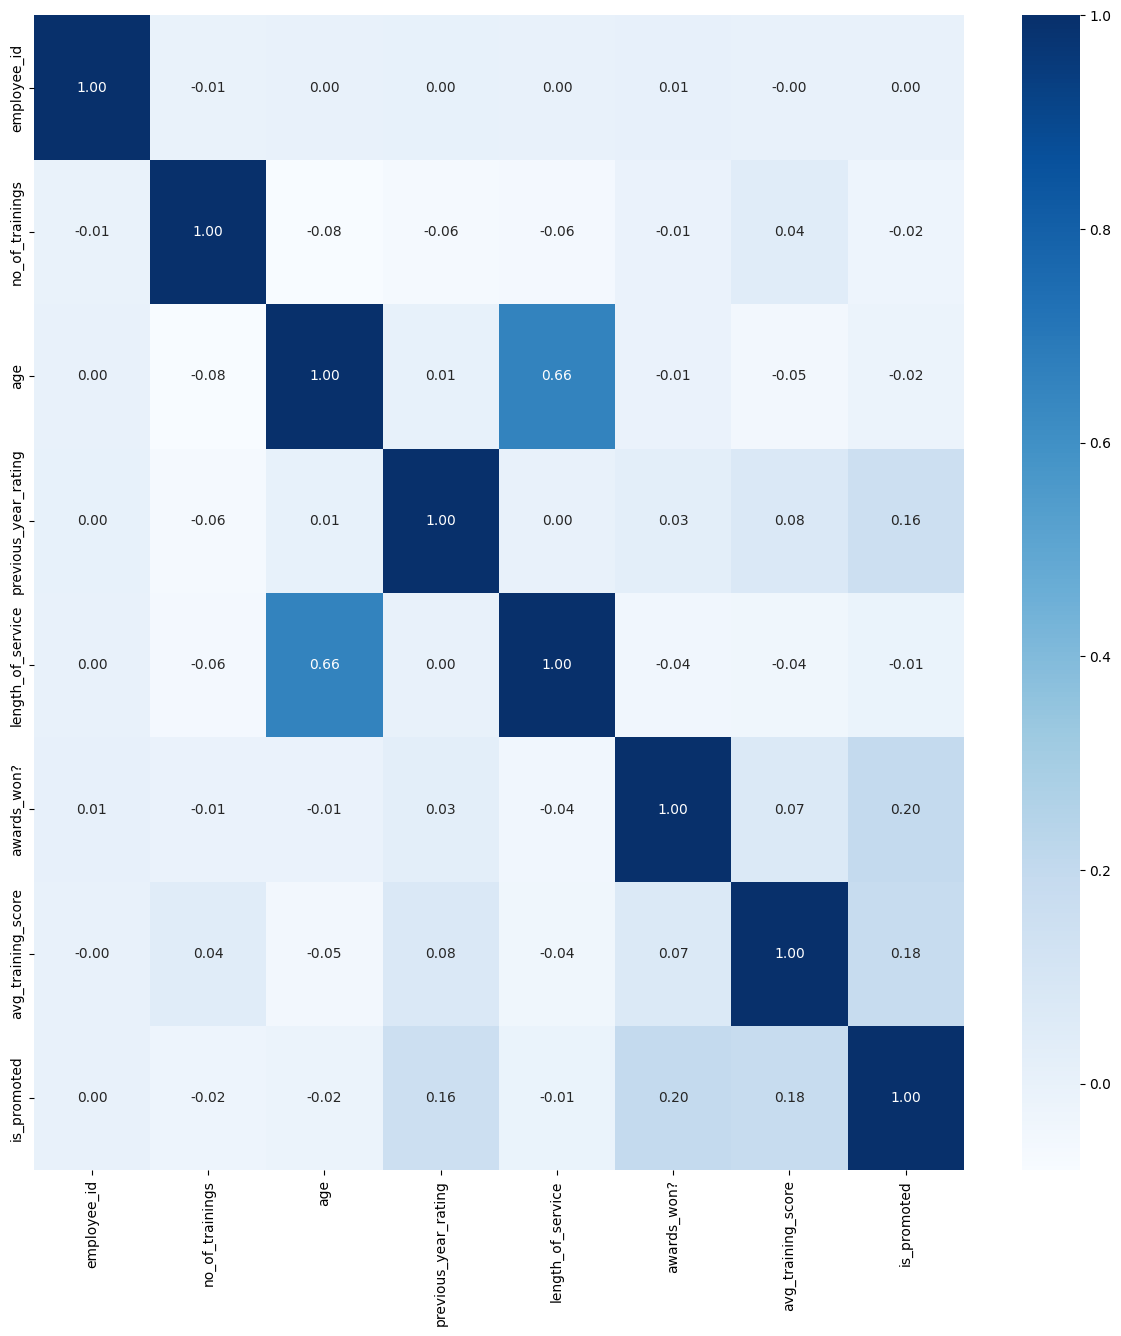

In [ ]:
plt.figure(figsize=(15, 15))
sns.heatmap(eda[num].corr(), cmap='Blues', annot=True, fmt='.2f')

<Axes: >

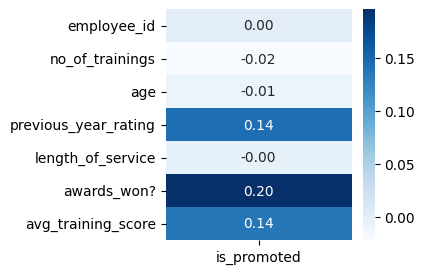

In [ ]:
# Create Heatmap Correlation Chart for Each Numerical to Target Features

plt.figure(figsize=(3, 3))
sns.heatmap(eda[num].corr(method = 'kendall')[eda[num].corr(method = 'kendall').index != 'is_promoted'][['is_promoted']], cmap='Blues', annot=True, fmt='.2f')

# Data Pre Processing

## Handling Missing Values

In [ ]:
print('Data Train Missing Values :')
df_train.isnull().sum()/len(df_train)*100

Data Train Missing Values :


,0
employee_id,0.000000
department,0.000000
region,0.000000
education,4.395344
gender,0.000000
recruitment_channel,0.000000
no_of_trainings,0.000000
age,0.000000
previous_year_rating,7.524449
length_of_service,0.000000


### Education Feature Missing Value Imputation

In [ ]:
# check value counts
df_train['education'].value_counts()

,count
education,
Bachelor's,36669
Master's & above,14925
Below Secondary,805


In [ ]:
df_train[df_train['education'].isnull()].groupby('department').agg(count=('department','count'))

,count
department,
Analytics,337
Finance,36
HR,32
Legal,4
Operations,226
Procurement,72
R&D,28
Sales & Marketing,1575
Technology,99


In [ ]:
df_train[df_train['department']=='Sales & Marketing'].groupby('education').agg(count=('education','count'))

,count
education,
Bachelor's,11099
Master's & above,4166


We will impute `Bachelor's` for missing values because mostly missing values in education located in 'Sales & Marketing' in `department` and most of 'Sales & Marketing' `department` are from `Bachelor's` degree

In [ ]:
df_train['education'] = df_train['education'].fillna("Bachelor's")
df_train['education'].value_counts()

### previous_year_rating Feature Missing Values Imputation

In [ ]:
df_train['previous_year_rating'].describe()

,previous_year_rating
count,50684.000000
mean,3.329256
std,1.259993
min,1.000000
25%,3.000000
50%,3.000000
75%,4.000000
max,5.000000


In [ ]:
# impute with median values
df_train['previous_year_rating'] = df_train['previous_year_rating'].fillna(df_train['previous_year_rating'].median())

### Summary & Rechecking

In [ ]:
print('Data Train Missing Values :')
df_train.isnull().sum()/len(df_train)*100

Data Train Missing Values :


,0
employee_id,0.0
department,0.0
region,0.0
education,0.0
gender,0.0
recruitment_channel,0.0
no_of_trainings,0.0
age,0.0
previous_year_rating,0.0
length_of_service,0.0


## Duplicated Data

In [ ]:
print('Num of duplicated values :', df_train.duplicated().sum())

Num of duplicated values : 0


data is clean from duplicated rows, no need to drop duplicated values

## Outlier Handling

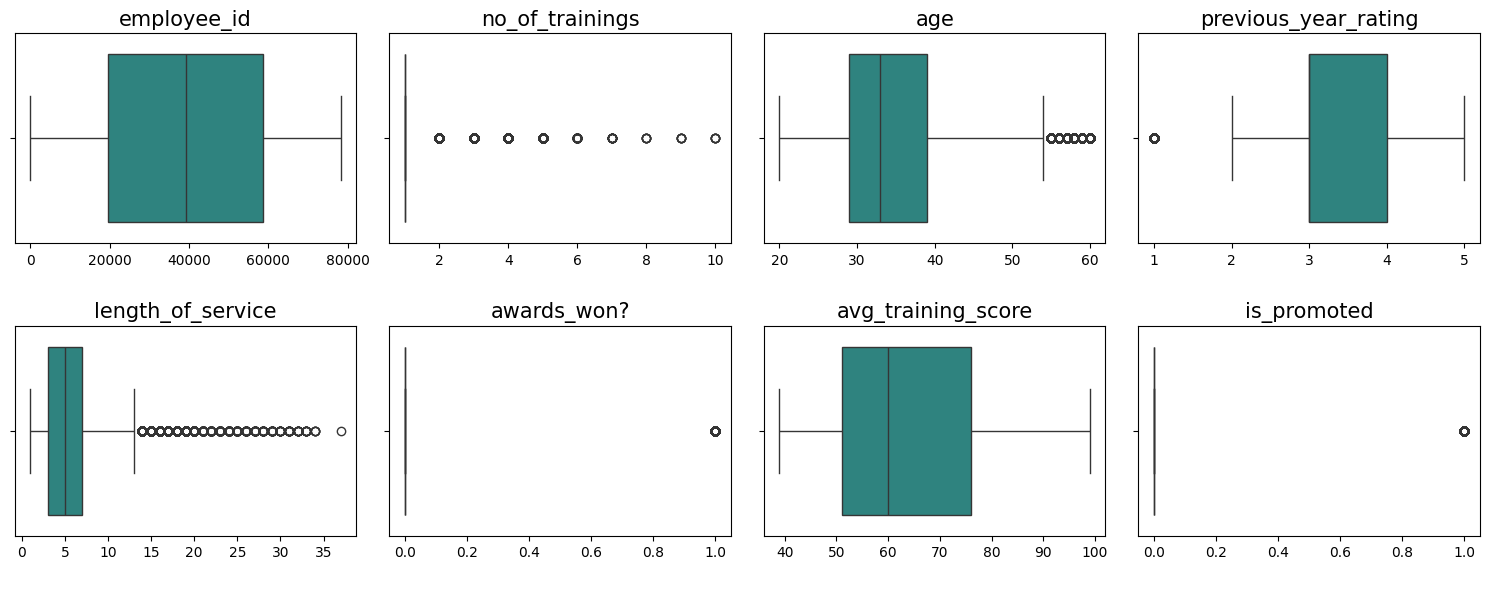

In [ ]:
plt.figure(figsize=(15,6))
for i in range(0, len(num)):
    plt.subplot(2,4,i+1)
    sns.boxplot(x=eda[num[i]], palette='viridis')
    plt.title(num[i], fontsize=15)
    plt.xlabel(' ')
    plt.tight_layout()

All values in numerical features are valid, we don't need to handle outlier

## Feature Encoding

### Train

In [ ]:
cat = df_train.select_dtypes(include='object').columns
cat

Index(['department', 'region', 'education', 'gender', 'recruitment_channel'], dtype='object')

In [ ]:
dummies = pd.get_dummies(df_train[cat], drop_first=True) #one hot encoding
dummies.head()

,department_Finance,department_HR,department_Legal,department_Operations,department_Procurement,department_R&D,department_Sales & Marketing,department_Technology,region_region_10,region_region_11,region_region_12,region_region_13,region_region_14,region_region_15,region_region_16,region_region_17,region_region_18,region_region_19,region_region_2,region_region_20,region_region_21,region_region_22,region_region_23,region_region_24,region_region_25,region_region_26,region_region_27,region_region_28,region_region_29,region_region_3,region_region_30,region_region_31,region_region_32,region_region_33,region_region_34,region_region_4,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,education_Below Secondary,education_Master's & above,gender_m,recruitment_channel_referred,recruitment_channel_sourcing
0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True
1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
3,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


In [ ]:
print('Original Num of Features :', df_train.shape[1])
print('Num Features Cat :', df_train[cat].shape[1])
print('Num Dummies Features :', dummies.shape[1])

Original Num of Features : 13
Num Features Cat : 5
Num Dummies Features : 46


In [ ]:
# drop original cat features
df_train = df_train.drop(cat, axis=1)

# concate dummies and df_train
df_train = pd.concat([df_train, dummies], axis=1)

# Num of df_train updated
print('Num of features :', df_train.shape[1])

Num of features : 54


In [ ]:
X = df_train.drop(['is_promoted','employee_id'], axis=1)
y = df_train['is_promoted']

### Test

In [ ]:
df_test[cat].columns

Index(['department', 'region', 'education', 'gender', 'recruitment_channel'], dtype='object')

In [ ]:
dummies_test = pd.get_dummies(df_test[cat], drop_first=True) #one hot encoding
dummies_test.head()

,department_Finance,department_HR,department_Legal,department_Operations,department_Procurement,department_R&D,department_Sales & Marketing,department_Technology,region_region_10,region_region_11,region_region_12,region_region_13,region_region_14,region_region_15,region_region_16,region_region_17,region_region_18,region_region_19,region_region_2,region_region_20,region_region_21,region_region_22,region_region_23,region_region_24,region_region_25,region_region_26,region_region_27,region_region_28,region_region_29,region_region_3,region_region_30,region_region_31,region_region_32,region_region_33,region_region_34,region_region_4,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,education_Below Secondary,education_Master's & above,gender_m,recruitment_channel_referred,recruitment_channel_sourcing
1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
5,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True


In [ ]:
print('Original Num of Features :', df_test.shape[1])
print('Num Features Cat :', df_test[cat].shape[1])
print('Num Dummies Features :', dummies_test.shape[1])

Original Num of Features : 12
Num Features Cat : 5
Num Dummies Features : 46


In [ ]:
# drop original cat features
df_test = df_test.drop(cat, axis=1)
df_test = df_test.drop('employee_id', axis=1)

# concate dummies and df_train
df_test = pd.concat([df_test, dummies_test], axis=1)

# Num of df_train updated
print('Num of features :', df_test.shape[1])

Num of features : 52


## Feature Selection

### Quassi Constant Feature

In [ ]:
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(
    threshold=0.01)  # 0.1 indicates 99% of observations approximately

sel.fit(X)  # fit finds the features with low variance

sum(sel.get_support()) # how many not quasi-constant?

np.int64(44)

In [ ]:
features_to_keep = X.columns[sel.get_support()]

## let's print the feature that will be removed by Quaasi Constant
quasi_constant = X.columns[~sel.get_support()]
quasi_constant

Index(['region_region_12', 'region_region_18', 'region_region_21',
       'region_region_24', 'region_region_3', 'region_region_33',
       'region_region_34', 'region_region_9'],
      dtype='object')

### Chi Square

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2


# we use default train data (without scaled and imbalace handled)
selector = SelectKBest(chi2,k=58)
fit = selector.fit(X, y)

dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)

In [ ]:
#concat two dataframes
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Features','Score']  #naming the dataframe columns
features_keep_chi = featureScores.nlargest(58,'Score')
features_keep_chi

,Features,Score
5,avg_training_score,5072.973743
4,awards_won?,2054.009313
2,previous_year_rating,574.656810
41,region_region_4,76.809911
27,region_region_22,69.467225
13,department_Technology,46.061828
12,department_Sales & Marketing,37.312181
48,education_Master's & above,34.340794
44,region_region_7,28.400044
21,region_region_17,27.374863


### Univariate feature selection

In [ ]:
# Import libraries
from sklearn.feature_selection import f_classif, f_regression

# calculate the univariate statistical measure between
# each of the variables and the target

# similarly to chi2, the output is one array with f-scores
# and one array with the pvalues

univariate = f_classif(X, y)

<Axes: >

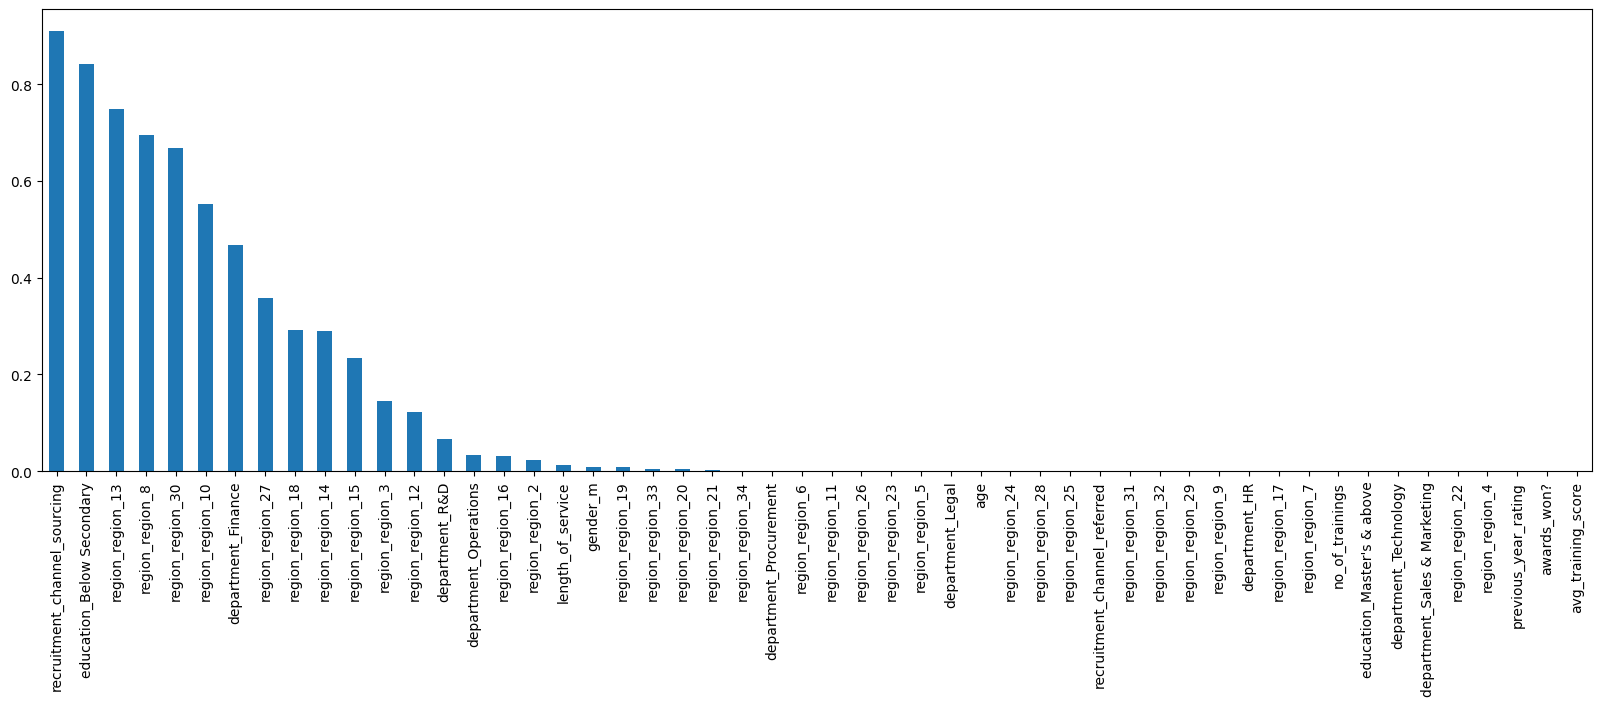

In [ ]:
# 1) let's capture the pvalues in a pandas series
# 2) add the variable names in the index
# 3) sort the features based on their anova pvalues
# 4) and make a var plot

univariate = pd.Series(univariate[1])
univariate.index = X.columns
univariate.sort_values(ascending=False).plot.bar(figsize=(20, 6))

- The smaller the p_value the more predictive the feature is.
- Features on the left of the plot are very bad at predicting the target. The most predictive features are on the right of the plot.

### Mutual Information

In [ ]:
# to obtain the mutual information values
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

# calculate the mutual information between the variables and the target

# the smaller the value of the mi, the less information we can infer from
# the feature about the target

mi = mutual_info_classif(X, y)

Text(0, 0.5, 'Mutual Information')

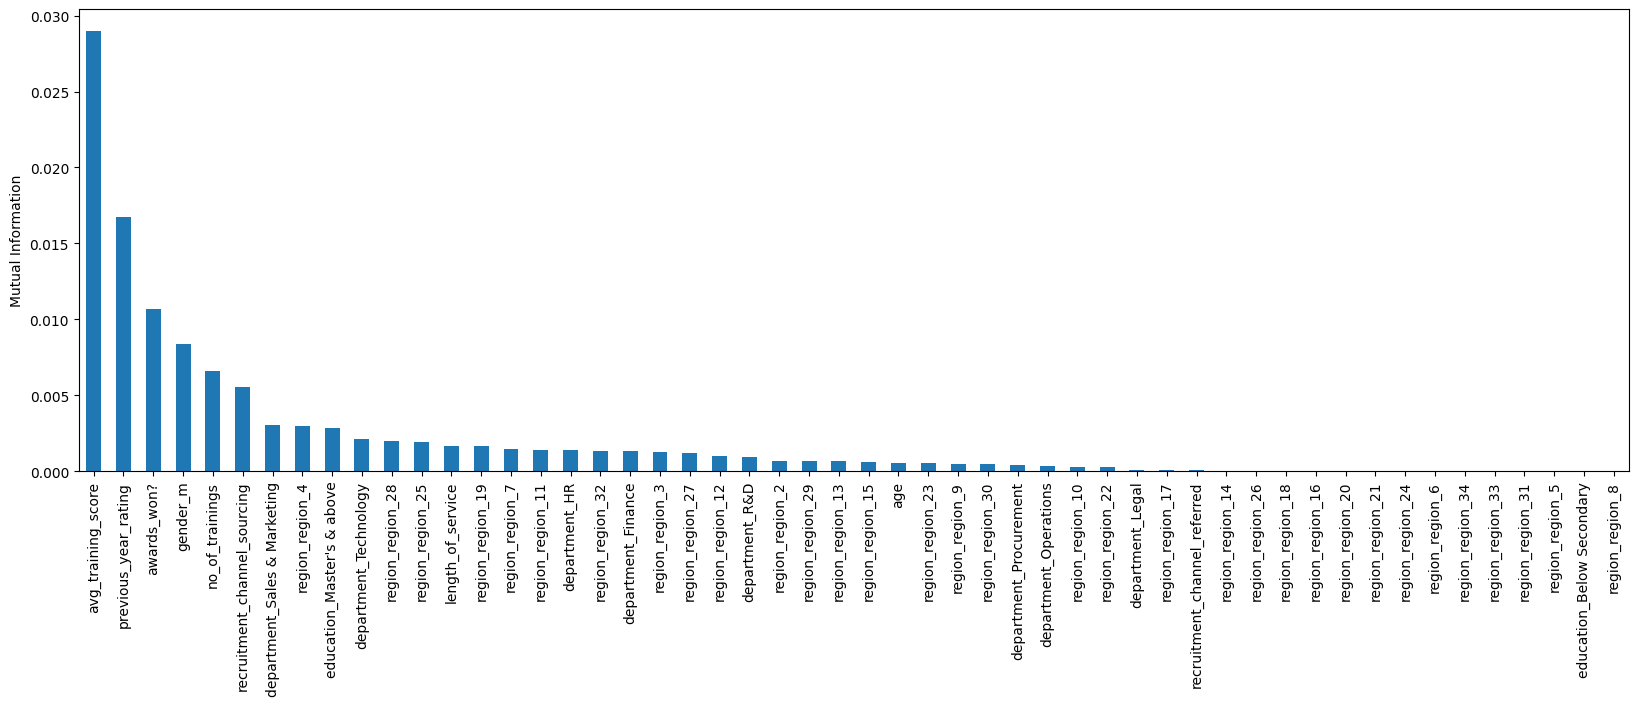

In [ ]:
# 1) let's capture the above array in a pandas series
# 2)add the variable names in the index
# 3) sort the features based on their mutual information value
# 4) and make a var plot

mi = pd.Series(mi)
mi.index = X.columns
mi.sort_values(ascending=False).plot.bar(figsize=(20, 6))
plt.ylabel('Mutual Information')

There are a few features (left of the plot) with higher mutual information values. There are also features with almost zero MI values on the right of the plot. The higher mutual information value the more predictive value is

### Lasso

In [ ]:
# Import Robust Scaler Library
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler

# Splitting Data Train - Test
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=123)

print(f'Total Train Data = {X_train.shape[0]}')
print(f'Total Test Data = {X_test.shape[0]}')

Total Train Data = 38365
Total Test Data = 16443


In [ ]:
# Declarate Scaler Function
# scaler = RobustScaler()
# scaler = StandardScaler()
scaler = MinMaxScaler()

# Fitting Scaler with Train Data
scaler.fit(X_train)

# Scaling Train and Test Data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Create DataFrame from Scaled Array Values

X_train_for_lasso = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_for_lasso = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [ ]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression

# fit a Lasso and selet features, make sure to select l1 # kalo pake lasso setelah transformasi

sel_ = SelectFromModel(
    LogisticRegression(C=0.5,
                       penalty='l1',
                       solver='liblinear',
                       random_state=123))

sel_.fit(scaler.transform(X_train_scaled), y_train)

# remove features with zero coefficient from dataset
# and parse again as dataframe

X_train_lasso = pd.DataFrame(sel_.transform(X_train_for_lasso))
X_test_lasso = pd.DataFrame(sel_.transform(X_test_for_lasso))

# add the columns name
X_train_lasso.columns = X_train_for_lasso.columns[(sel_.get_support())]
X_test_lasso.columns = X_test_for_lasso.columns[(sel_.get_support())]

In [ ]:
# let's print the feature that will be removed by Lasso
X_train_for_lasso.columns[(~sel_.get_support())]

Index(['no_of_trainings', 'length_of_service', 'department_HR',
       'region_region_10', 'region_region_14', 'region_region_18',
       'region_region_8', 'education_Below Secondary'],
      dtype='object')

### Summary

In [ ]:
quasi_constant

Index(['region_region_12', 'region_region_18', 'region_region_21',
       'region_region_24', 'region_region_3', 'region_region_33',
       'region_region_34', 'region_region_9'],
      dtype='object')

In [ ]:
quasi = ['region_region_12', 'region_region_18', 'region_region_21',
         'region_region_24', 'region_region_3', 'region_region_33',
         'region_region_34', 'region_region_9']

lasso =  ['department_Finance', 'region_region_10',
          'region_region_14', 'region_region_26',
          'region_region_8', 'gender_f',
          'recruitment_channel_referred']

print('Len Quasi', len(quasi))
print('Lasso', len(lasso))

Len Quasi 8
Lasso 7


In [ ]:
# Summary of all feature selection method + business acumen
col = ['avg_training_score', 'awards_won?', 'previous_year_rating', 'age', 'gender_m',
       "education_Master's & above", 'no_of_trainings', 'length_of_service']

## Handling Imbalaced Target

In [ ]:
# check how imbalance the targe is
y.value_counts()/len(y)*100

,count
is_promoted,
0,91.482995
1,8.517005


In [ ]:
# Import Robust Scaler Library
from sklearn.model_selection import train_test_split

# Splitting Data Train - Test
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=21)

print(f'Total Train Data = {X_train.shape[0]}')
print(f'Total Test Data = {X_test.shape[0]}')

Total Train Data = 38365
Total Test Data = 16443


In [ ]:
from imblearn.over_sampling import SMOTE

# Random Over Sampling
sm = SMOTE(random_state=123, sampling_strategy=0.5)
sm.fit(X_train, y_train)
X_smote, y_smote = sm.fit_resample(X_train, y_train)

In [ ]:
print('X_train shape :', X_train.shape)
print('y_train shape :', y_train.shape)
print('X_smote shape :', X_smote.shape)
print('y_smote shape :', y_smote.shape)

X_train shape : (38365, 52)
y_train shape : (38365,)
X_smote shape : (52735, 52)
y_smote shape : (52735,)


# Modeling

In [ ]:
# Import Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix

## Basic Modeling

In [ ]:
lr_sm = LogisticRegression()
dt_sm = DecisionTreeClassifier()
rf_sm = RandomForestClassifier()
ab_sm = AdaBoostClassifier()
gb_sm = GradientBoostingClassifier()
xg_sm = XGBClassifier()


# Train the Model
lr_sm.fit(X_smote, y_smote)
dt_sm.fit(X_smote, y_smote)
rf_sm.fit(X_smote, y_smote)
ab_sm.fit(X_smote, y_smote)
gb_sm.fit(X_smote, y_smote)
xg_sm.fit(X_smote, y_smote)

# Predictions for the X test
y_pred_lr_sm = lr_sm.predict(X_test)
y_pred_dt_sm = dt_sm.predict(X_test)
y_pred_rf_sm = rf_sm.predict(X_test)
y_pred_ab_sm = lr_sm.predict(X_test)
y_pred_gb_sm = gb_sm.predict(X_test)
y_pred_xg_sm = xg_sm.predict(X_test)

In [ ]:
abcd = [['Logistic Regression', accuracy_score(y_test, y_pred_lr_sm), precision_score(y_test, y_pred_lr_sm),
          recall_score(y_test, y_pred_lr_sm), f1_score(y_test, y_pred_lr_sm)],
        ['Decision Tree', accuracy_score(y_test, y_pred_dt_sm), precision_score(y_test, y_pred_dt_sm),
          recall_score(y_test, y_pred_dt_sm), f1_score(y_test, y_pred_dt_sm)],
        ['Random Forest', accuracy_score(y_test, y_pred_rf_sm), precision_score(y_test, y_pred_rf_sm),
          recall_score(y_test, y_pred_rf_sm), f1_score(y_test, y_pred_rf_sm)],
        ['Ada Boost', accuracy_score(y_test, y_pred_ab_sm), precision_score(y_test, y_pred_ab_sm),
          recall_score(y_test, y_pred_ab_sm), f1_score(y_test, y_pred_ab_sm)],
        ['Gradient Boost', accuracy_score(y_test, y_pred_gb_sm), precision_score(y_test, y_pred_gb_sm),
          recall_score(y_test, y_pred_gb_sm), f1_score(y_test, y_pred_gb_sm)],
        ['XG Boost', accuracy_score(y_test, y_pred_xg_sm), precision_score(y_test, y_pred_xg_sm),
          recall_score(y_test, y_pred_xg_sm), f1_score(y_test, y_pred_xg_sm)]]

df_score = pd.DataFrame(abcd,columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
df_score

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.866569,0.263226,0.279452,0.271096
1,Decision Tree,0.875996,0.331588,0.390411,0.358603
2,Random Forest,0.924527,0.659389,0.310274,0.421984
3,Ada Boost,0.866569,0.263226,0.279452,0.271096
4,Gradient Boost,0.922216,0.612702,0.336986,0.434821
5,XG Boost,0.937055,0.813885,0.377397,0.515676


In [ ]:
# feature importance
def show_feature_importance(model):
    feat_importances = pd.Series(model.feature_importances_, index=X_smote.columns)
    ax = feat_importances.nlargest(25).plot(kind='barh', figsize=(5, 5))
    ax.invert_yaxis()

    plt.xlabel('score')
    plt.ylabel('feature')
    plt.title(model, fontsize=10)

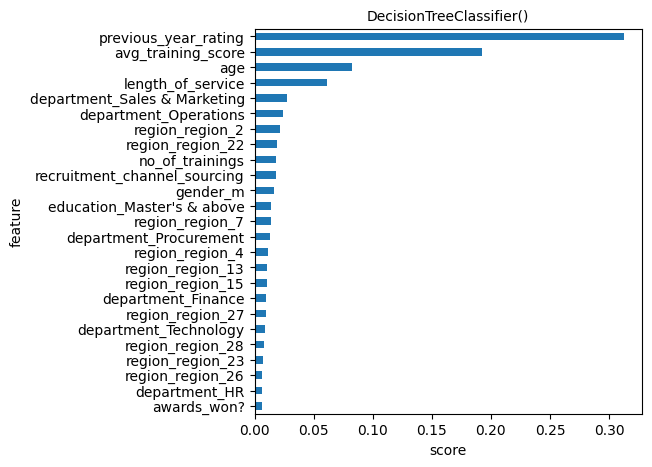

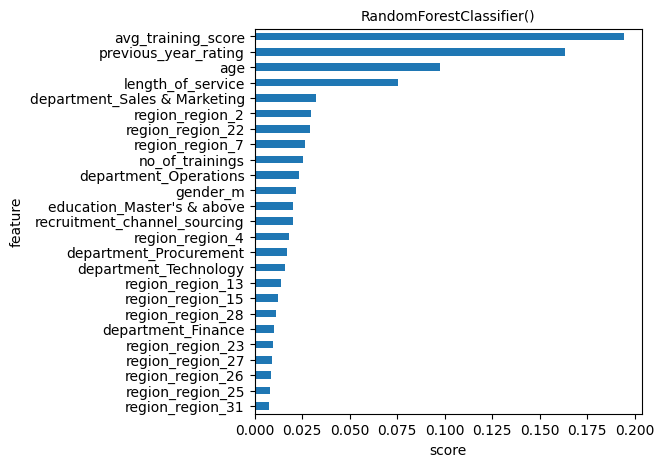

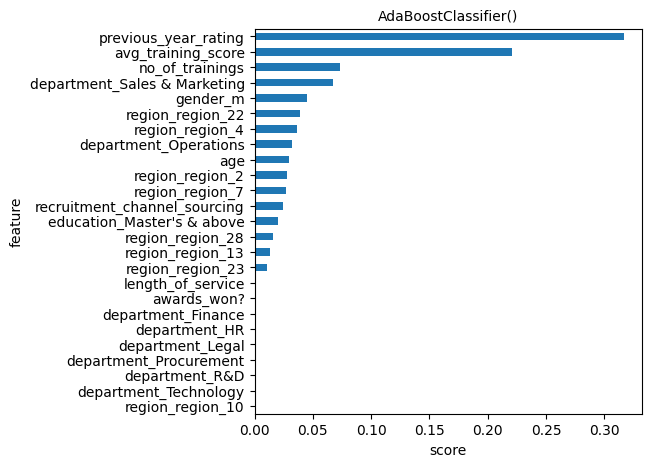

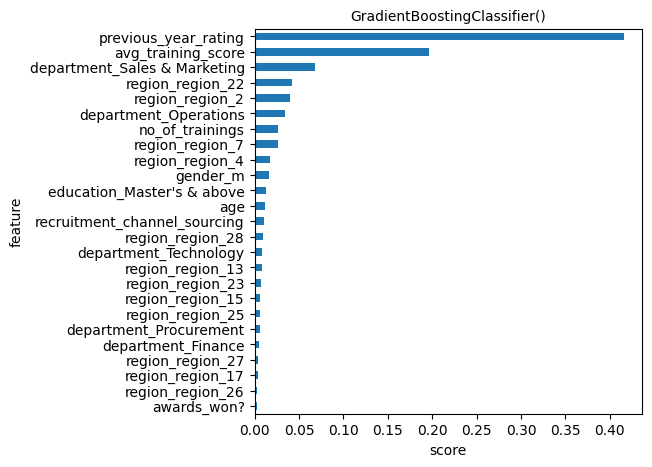

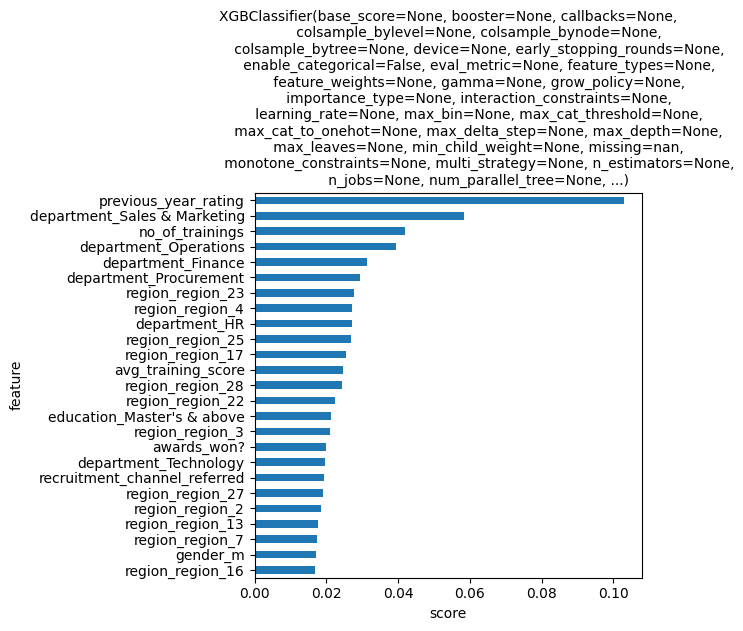

In [ ]:
model = [dt_sm, rf_sm, ab_sm, gb_sm, xg_sm]

for i in model:
    show_feature_importance(i)
    plt.show()

In [ ]:
col2 = ['previous_year_rating', "education_Master's & above",
        'department_Procurement', 'avg_training_score', 'department_Technology']

## Basic Modeling Using Selected Feature in Feature Selection

In [ ]:
lr_sm = LogisticRegression()
dt_sm = DecisionTreeClassifier()
rf_sm = RandomForestClassifier()
ab_sm = AdaBoostClassifier()
gb_sm = GradientBoostingClassifier()
xg_sm = XGBClassifier()


# Train the Model
lr_sm.fit(X_smote[col], y_smote)
dt_sm.fit(X_smote[col], y_smote)
rf_sm.fit(X_smote[col], y_smote)
ab_sm.fit(X_smote[col], y_smote)
gb_sm.fit(X_smote[col], y_smote)
xg_sm.fit(X_smote[col], y_smote)

# Predictions for the X test
y_pred_lr_sm = lr_sm.predict(X_test[col])
y_pred_dt_sm = dt_sm.predict(X_test[col])
y_pred_rf_sm = rf_sm.predict(X_test[col])
y_pred_ab_sm = lr_sm.predict(X_test[col])
y_pred_gb_sm = gb_sm.predict(X_test[col])
y_pred_xg_sm = xg_sm.predict(X_test[col])

In [ ]:
abcd = [['Logistic Regression', accuracy_score(y_test, y_pred_lr_sm), precision_score(y_test, y_pred_lr_sm),
          recall_score(y_test, y_pred_lr_sm), f1_score(y_test, y_pred_lr_sm)],
        ['Decision Tree', accuracy_score(y_test, y_pred_dt_sm), precision_score(y_test, y_pred_dt_sm),
          recall_score(y_test, y_pred_dt_sm), f1_score(y_test, y_pred_dt_sm)],
        ['Random Forest', accuracy_score(y_test, y_pred_rf_sm), precision_score(y_test, y_pred_rf_sm),
          recall_score(y_test, y_pred_rf_sm), f1_score(y_test, y_pred_rf_sm)],
        ['Ada Boost', accuracy_score(y_test, y_pred_ab_sm), precision_score(y_test, y_pred_ab_sm),
          recall_score(y_test, y_pred_ab_sm), f1_score(y_test, y_pred_ab_sm)],
        ['Gradient Boost', accuracy_score(y_test, y_pred_gb_sm), precision_score(y_test, y_pred_gb_sm),
          recall_score(y_test, y_pred_gb_sm), f1_score(y_test, y_pred_gb_sm)],
        ['XG Boost', accuracy_score(y_test, y_pred_xg_sm), precision_score(y_test, y_pred_xg_sm),
          recall_score(y_test, y_pred_xg_sm), f1_score(y_test, y_pred_xg_sm)]]

df_score = pd.DataFrame(abcd,columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
df_score

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.835492,0.227571,0.356164,0.277704
1,Decision Tree,0.835553,0.200385,0.284932,0.235294
2,Random Forest,0.865171,0.251803,0.263014,0.257286
3,Ada Boost,0.835492,0.227571,0.356164,0.277704
4,Gradient Boost,0.893024,0.368975,0.288356,0.323722
5,XG Boost,0.878611,0.304665,0.286301,0.295198


In [ ]:
# feature importance
def show_feature_importance(model):
    feat_importances = pd.Series(model.feature_importances_, index=X_smote[col].columns)
    ax = feat_importances.nlargest(25).plot(kind='barh', figsize=(5, 5))
    ax.invert_yaxis()

    plt.xlabel('score')
    plt.ylabel('feature')
    plt.title(model, fontsize=10)

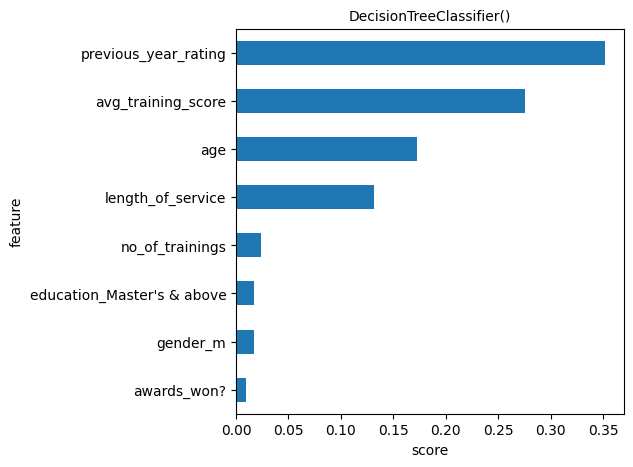

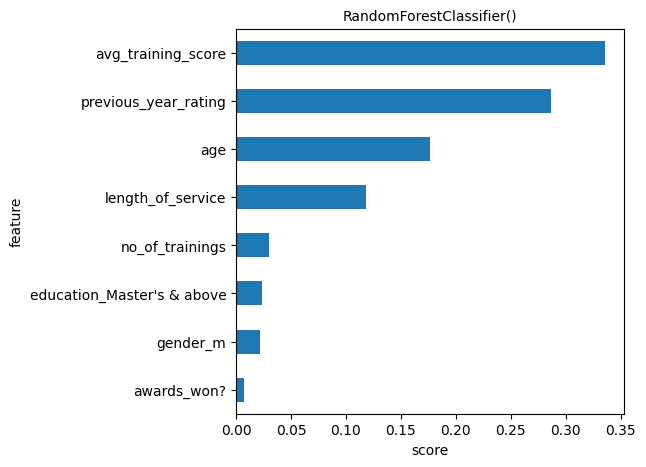

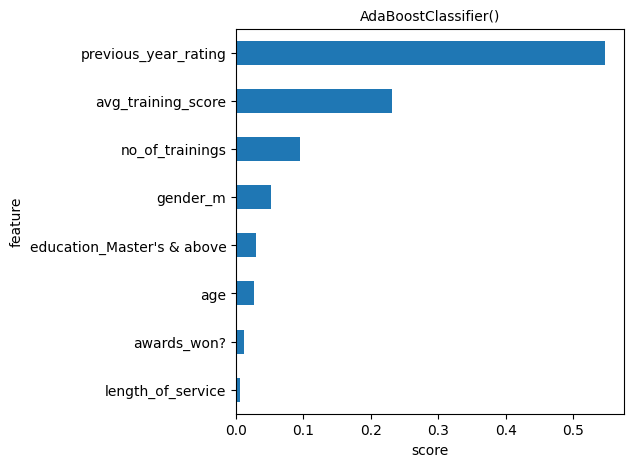

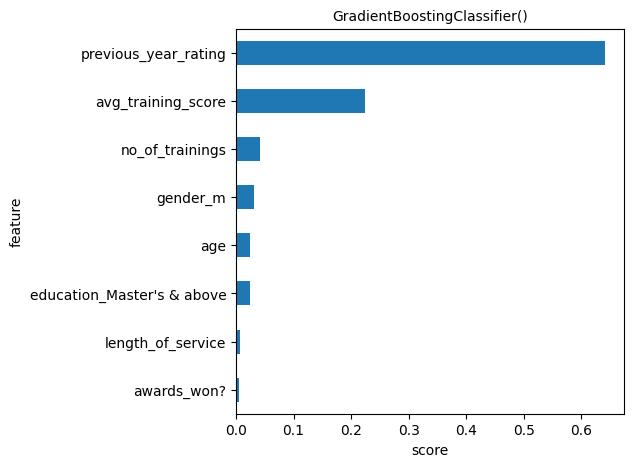

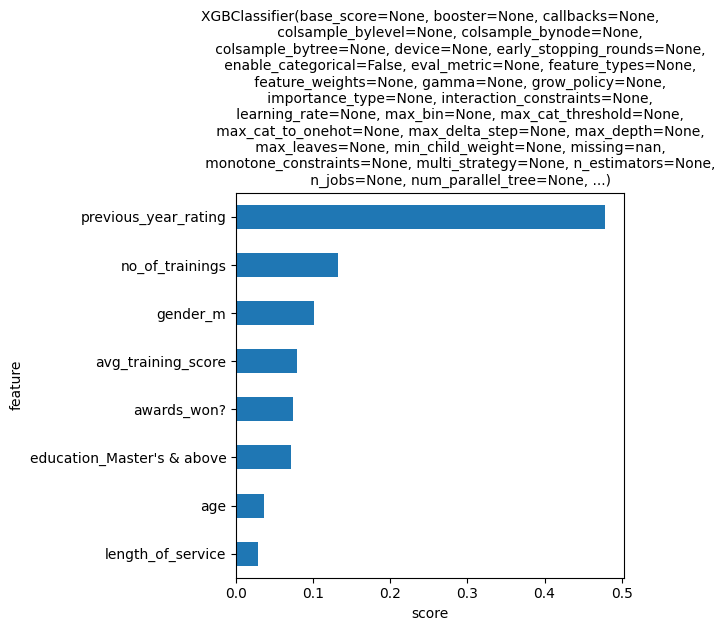

In [ ]:
model = [dt_sm, rf_sm, ab_sm, gb_sm, xg_sm]

for i in model:
    show_feature_importance(i)
    plt.show()

## Hyperparameter

### Random Forest Hyperparameter

max_depth: 1; train: 0.0; test: 0.0
max_depth: 2; train: 0.8888888888888888; test: 0.96
max_depth: 3; train: 0.8354978354978355; test: 0.8854166666666666
max_depth: 5; train: 0.6265984654731458; test: 0.6455331412103746
max_depth: 6; train: 0.5969331872946331; test: 0.6287878787878788
max_depth: 7; train: 0.5481099656357389; test: 0.5522682445759369
max_depth: 9; train: 0.5235816814764184; test: 0.505564387917329
max_depth: 10; train: 0.5995370370370371; test: 0.5767195767195767
max_depth: 11; train: 0.6037868162692848; test: 0.55810147299509
max_depth: 13; train: 0.663013698630137; test: 0.5864406779661017
max_depth: 14; train: 0.7017310252996005; test: 0.5912762520193862
max_depth: 15; train: 0.7302931596091206; test: 0.5912762520193862
max_depth: 17; train: 0.815932407966204; test: 0.6341463414634146
max_depth: 18; train: 0.8568935427574171; test: 0.6442006269592476
max_depth: 19; train: 0.8878186968838527; test: 0.6527331189710611
max_depth: 21; train: 0.9277412834765033; test: 0.6

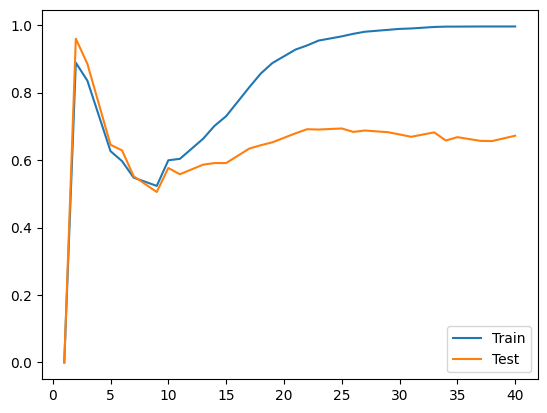

In [ ]:
#values = ['gini','entropy'] #criterion
values = [int(x) for x in np.linspace(1,40,30)] #max_depth
#values = [int)x for x in np.linspace(0,40,30)] #min_samples_split
#values = [int)x for x in np.linspace(0,40,30)] #min_samples_leaf
#values = ['auto', 'sqrt', 'log2'] #max_features

train_score = []
test_score = []

for x in values :
    model_rf = RandomForestClassifier(max_depth=x,
                                      random_state=2)

    model_rf.fit(X_smote,y_smote)

    # eval on train
    y_pred_train = model_rf.predict(X_train)
    train_prec = precision_score(y_train, y_pred_train)
    train_score.append(train_prec)

    # eval on test
    y_pred_test = model_rf.predict(X_test)
    test_prec = precision_score(y_test, y_pred_test)
    test_score.append(test_prec)

    print('max_depth: ' + str(x) + '; train: ' + str(train_prec) + '; test: ' + str(test_prec))

plt.plot(values, train_score, label='Train')
plt.plot(values, test_score, label='Test')
plt.legend()
plt.show()

`max_depth`: 3; train: 0.8755555555555555; test: 0.9230769230769231

min_samples_leaf: 2; train: 0.8354978354978355; test: 0.8854166666666666
min_samples_leaf: 3; train: 0.8354978354978355; test: 0.8854166666666666
min_samples_leaf: 4; train: 0.8354978354978355; test: 0.8854166666666666
min_samples_leaf: 5; train: 0.8362068965517241; test: 0.8865979381443299
min_samples_leaf: 7; train: 0.8362068965517241; test: 0.8865979381443299
min_samples_leaf: 8; train: 0.8362068965517241; test: 0.8865979381443299
min_samples_leaf: 9; train: 0.8362068965517241; test: 0.8865979381443299
min_samples_leaf: 11; train: 0.8362068965517241; test: 0.8865979381443299
min_samples_leaf: 12; train: 0.8326180257510729; test: 0.8865979381443299
min_samples_leaf: 13; train: 0.8318965517241379; test: 0.8854166666666666
min_samples_leaf: 15; train: 0.8318965517241379; test: 0.8854166666666666
min_samples_leaf: 16; train: 0.8318965517241379; test: 0.8854166666666666
min_samples_leaf: 17; train: 0.8318965517241379; test: 0.8854166666666666
min_samples_leaf: 19; train: 0.83261802575107

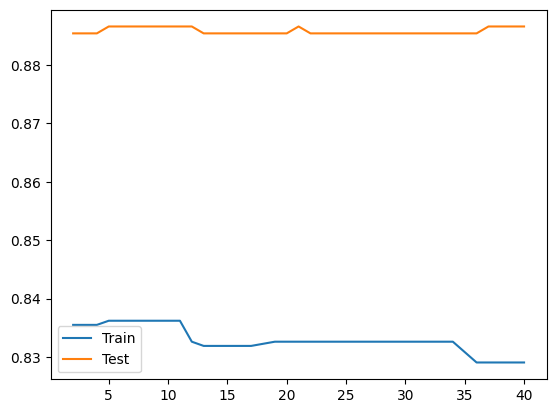

In [ ]:
#values = ['gini','entropy'] #criterion
#values = [int(x) for x in np.linspace(1,40,30)] #max_depth
#values = [int(x) for x in np.linspace(3,40,30)] #min_samples_split
values = [int(x) for x in np.linspace(2,40,30)] #min_samples_leaf
#values = ['auto', 'sqrt', 'log2'] #max_features

train_score = []
test_score = []

for x in values :
    model_rf = RandomForestClassifier(max_depth=3,
                                      random_state=2,
                                      min_samples_leaf=x)

    model_rf.fit(X_smote,y_smote)

    # eval on train
    y_pred_train = model_rf.predict(X_train)
    train_auc = precision_score(y_train, y_pred_train)
    train_score.append(train_auc)

    # eval on test
    y_pred_test = model_rf.predict(X_test)
    test_auc = precision_score(y_test, y_pred_test)
    test_score.append(test_auc)

    print('min_samples_leaf: ' + str(x) + '; train: ' + str(train_auc) + '; test: ' + str(test_auc))

plt.plot(values, train_score, label='Train')
plt.plot(values, test_score, label='Test')
plt.legend()
plt.show()

`min_samples_leaf`: 5; train: 0.8783783783783784; test: 0.9213483146067416

criterion: gini; train: 0.8362068965517241; test: 0.8865979381443299
criterion: entropy; train: 0.8599221789883269; test: 0.9345794392523364


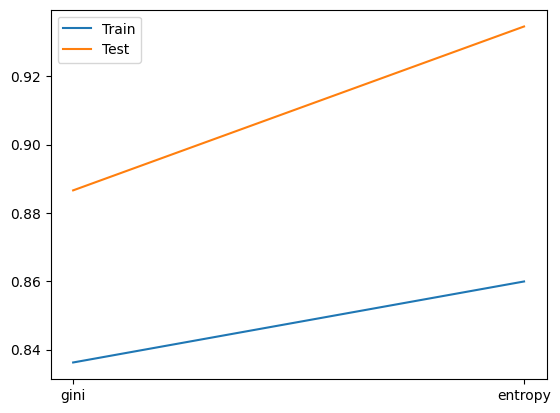

In [ ]:
values = ['gini','entropy'] #criterion
#values = [int(x) for x in np.linspace(1,40,30)] #max_depth
#values = [int(x) for x in np.linspace(3,40,30)] #min_samples_split
#values = [int(x) for x in np.linspace(2,40,30)] #min_samples_leaf
#values = ['auto', 'sqrt', 'log2'] #max_features

train_score = []
test_score = []

for x in values :
    model_rf = RandomForestClassifier(max_depth=3,
                                      random_state=2,
                                      min_samples_leaf=5,
                                      criterion=x)

    model_rf.fit(X_smote,y_smote)

    # eval on train
    y_pred_train = model_rf.predict(X_train)
    train_auc = precision_score(y_train, y_pred_train)
    train_score.append(train_auc)

    # eval on test
    y_pred_test = model_rf.predict(X_test)
    test_auc = precision_score(y_test, y_pred_test)
    test_score.append(test_auc)

    print('criterion: ' + str(x) + '; train: ' + str(train_auc) + '; test: ' + str(test_auc))

plt.plot(values, train_score, label='Train')
plt.plot(values, test_score, label='Test')
plt.legend()
plt.show()

max_features: sqrt; train: 0.8599221789883269; test: 0.9345794392523364
max_features: log2; train: 0.911504424778761; test: 1.0


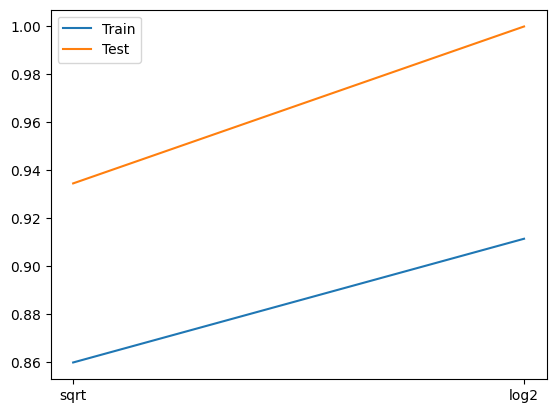

In [ ]:
#values = ['gini','entropy'] #criterion
#values = [int(x) for x in np.linspace(1,40,30)] #max_depth
#values = [int(x) for x in np.linspace(3,40,30)] #min_samples_split
#values = [int(x) for x in np.linspace(2,40,30)] #min_samples_leaf
values = ['sqrt', 'log2'] #max_features # Corrected 'auto' to 'sqrt'

train_score = []
test_score = []

for x in values :
    model_rf = RandomForestClassifier(max_depth=3,
                                      random_state=2,
                                      min_samples_leaf=5,
                                      criterion='entropy',
                                      max_features=x) # Use 'x' directly as it will be 'sqrt' or 'log2'

    model_rf.fit(X_smote,y_smote)

    # eval on train
    y_pred_train = model_rf.predict(X_train)
    train_auc = precision_score(y_train, y_pred_train)
    train_score.append(train_auc)

    # eval on test
    y_pred_test = model_rf.predict(X_test)
    test_auc = precision_score(y_test, y_pred_test)
    test_score.append(test_auc)

    print('max_features: ' + str(x) + '; train: ' + str(train_auc) + '; test: ' + str(test_auc))

plt.plot(values, train_score, label='Train')
plt.plot(values, test_score, label='Test')
plt.legend()
plt.show()

In [ ]:
model_rf = RandomForestClassifier(max_depth=3,
                                      random_state=2,
                                      min_samples_leaf=5,
                                      criterion='entropy',
                                      max_features='sqrt')

model_rf.fit(X_smote,y_smote)

# eval on train
y_pred_train = model_rf.predict(X_train)
train_prec = precision_score(y_train, y_pred_train)

# eval on test
y_pred_test = model_rf.predict(X_test)
test_prec = precision_score(y_test, y_pred_test)

print('Precision Train Score :', train_prec)
print('Precision Test Score :', test_prec)

Precision Train Score : 0.8599221789883269
Precision Test Score : 0.9345794392523364


In [ ]:
# feature importance
def show_feature_importance(model, title):
    feat_importances = pd.Series(model.feature_importances_, index=X_smote.columns)
    ax = feat_importances.nlargest(25).plot(kind='barh', figsize=(5, 5))
    ax.invert_yaxis()

    plt.xlabel('score')
    plt.ylabel('feature')
    plt.title(title, fontsize=10)

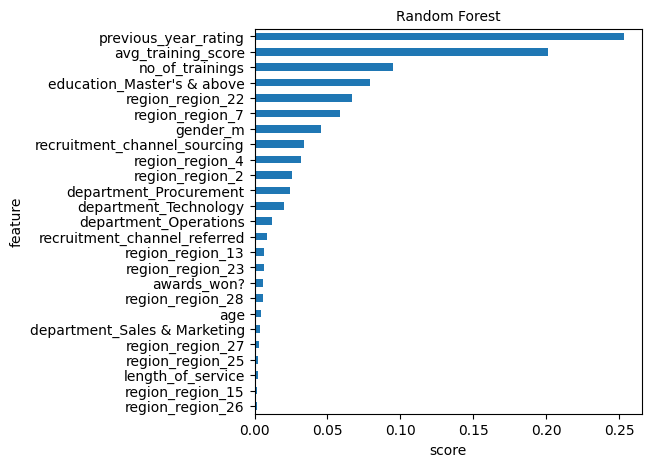

In [ ]:
show_feature_importance(model_rf, 'Random Forest')

### XGBClassifier Hyperparameter

max_depth: 1; train: 0.3982646420824295; test: 0.40236686390532544
max_depth: 3; train: 0.7619387027797576; test: 0.7942073170731707
max_depth: 5; train: 0.8423295454545454; test: 0.8286163522012578
max_depth: 7; train: 0.8508604206500956; test: 0.7948717948717948
max_depth: 9; train: 0.8985915492957747; test: 0.7570469798657719
max_depth: 11; train: 0.9328859060402684; test: 0.7285531370038413
max_depth: 13; train: 0.9654190398698128; test: 0.6869671132764921
max_depth: 15; train: 0.9802015838732901; test: 0.6678445229681979
max_depth: 17; train: 0.9889595182335229; test: 0.6662817551963048
max_depth: 20; train: 0.9949510886715052; test: 0.6596244131455399


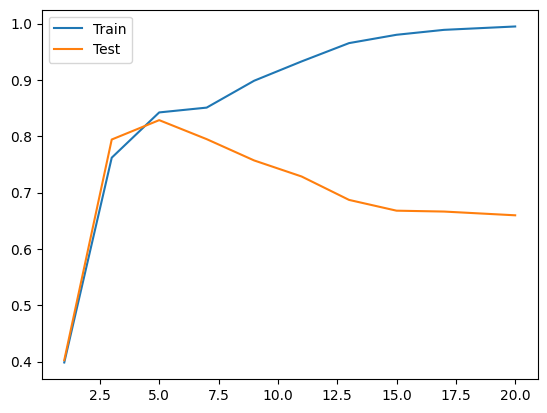

In [ ]:
# values = [int(x) for x in np.linspace(start=1, stop=20, num=10)] # max_depth
# #values = [int(x) for x in np.linspace(start=2, stop=200, num=35)] # min_child_weight
# #values = [float(x) for x in np.linspace(start=0, stop=1, num=25)] # gamma
# #values = ['auto', 'exact', 'approx', 'hist'] # tree_method
# #values = [float(x) for x in np.linspace(start = 0, stop = 1, num = 30)] # colsample_bytree
# #values = [float(x) for x in np.linspace(0, 1, num = 100)] #eta
# #values = [float(x) for x in np.linspace(0, 1, num = 100)] #lambda
# #values = [float(x) for x in np.linspace(0, 1, num = 100)] #alpha

# train_score = []
# test_score = []

# for x in values :
#     model_xg_tunned = XGBClassifier(max_depth=x,
#                                     random_state=3,
#                                     verbosity=0)
#     model_xg_tunned.fit(X_smote,y_smote)

#     # eval on train
#     y_pred_train_xg = model_xg_tunned.predict(X_train)
#     train_prec = precision_score(y_train, y_pred_train_xg)
#     train_score.append(train_prec)

#     # eval on test
#     y_pred_test_xg = model_xg_tunned.predict(X_test)
#     test_prec = precision_score(y_test, y_pred_test_xg)
#     test_score.append(test_prec)

#     print('max_depth: ' + str(x) + '; train: ' + str(train_prec) + '; test: ' + str(test_prec))

# plt.plot(values, train_score, label='Train')
# plt.plot(values, test_score, label='Test')
# plt.legend()
# plt.show()

we're not gonna continue using this algorithm because too overfiting and we also have already found the better algorithm (Random Forest)

### Gradient Boost Hyperparameter

max_depth: 1; train: 0.3624941833410889; test: 0.3736842105263158
max_depth: 2; train: 0.5455116133082235; test: 0.5597122302158274
max_depth: 3; train: 0.5873544093178037; test: 0.6127023661270237
max_depth: 5; train: 0.7347994825355757; test: 0.7521613832853026
max_depth: 6; train: 0.7688802083333334; test: 0.7679083094555874
max_depth: 7; train: 0.789776357827476; test: 0.7710674157303371
max_depth: 9; train: 0.8396624472573839; test: 0.7641379310344828
max_depth: 10; train: 0.8738028169014085; test: 0.7554054054054054
max_depth: 11; train: 0.9077490774907749; test: 0.7406914893617021
max_depth: 13; train: 0.9553349875930521; test: 0.7117117117117117
max_depth: 14; train: 0.9767964071856288; test: 0.6982323232323232
max_depth: 15; train: 0.9882839421088904; test: 0.6806930693069307
max_depth: 17; train: 0.9968523764557758; test: 0.6550060313630881
max_depth: 18; train: 0.9971875; test: 0.6458583433373349
max_depth: 20; train: 0.9971892567145534; test: 0.5905077262693157


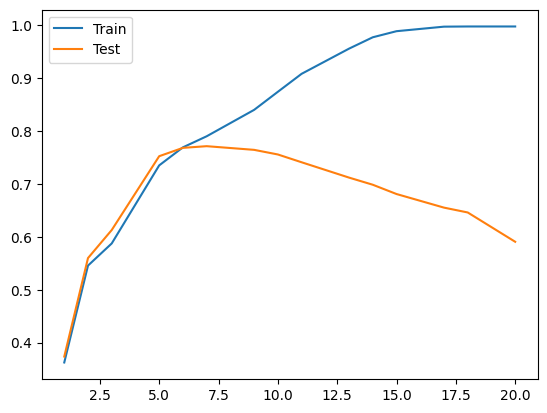

In [ ]:
# values = [int(x) for x in np.linspace(start=1, stop=20, num=15)] # max_depth
# #values = [int(x) for x in np.linspace(start=2, stop=200, num=35)] # min_samples_split
# #values = [int(x) for x in np.linspace(start=1, stop=120, num=25)] # min_samples_leaf
# #values = ['friedman_mse', 'squared_error'', 'mse'}] # criterion
# #values = [int(x) for x in np.linspace(start = 3, stop = 75, num = 30)] # n_estimators
# #values = ['auto', 'sqrt', 'log2'] #max_features
# #vallues = [float(x) for x in np.linspace(start = 0.001, stop = 0.1, num = 20)] #learning_rate


# train_score = []
# test_score = []

# for x in values :
#     model_gb_tunned = GradientBoostingClassifier(max_depth=x, random_state=4)
#     model_gb_tunned.fit(X_smote,y_smote)

#     # eval on train
#     y_pred_train_gb_sn = model_gb_tunned.predict(X_train)
#     train_precision = precision_score(y_train, y_pred_train_gb_sn)
#     train_score.append(train_precision)

#     # eval on test
#     y_pred_test_gb_sn = model_gb_tunned.predict(X_test)
#     test_precision = precision_score(y_test, y_pred_test_gb_sn)
#     test_score.append(test_precision)

#     print('max_depth: ' + str(x) + '; train: ' + str(train_precision) + '; test: ' + str(test_precision))

# plt.plot(values, train_score, label='Train')
# plt.plot(values, test_score, label='Test')
# plt.legend()
# plt.show()

we're not gonna continue using this algorithm because too overfiting and we also have already found the better algorithm (Random Forest)

# Business Simulation

## Confusion Matrix

In [ ]:
cf_matrix = confusion_matrix(y_test, y_pred_test)

group_names = ["True Positive", "False Negative", "False Positive", "True Negative"]
group_counts = ["{0:0.0f}".format(value) for value in cf_matrix.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cf_matrix.flatten()/np.sum(cf_matrix)]

labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(6, 6))
sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='Blues')

<Axes: >

In [ ]:
# feature importance
def show_feature_importance(model, title):
    feat_importances = pd.Series(model.feature_importances_, index=X_smote.columns)
    ax = feat_importances.nlargest(10).plot(kind='barh', figsize=(5, 5))
    ax.invert_yaxis()

    plt.xlabel('score')
    plt.ylabel('feature')
    plt.title(title, fontsize=10)

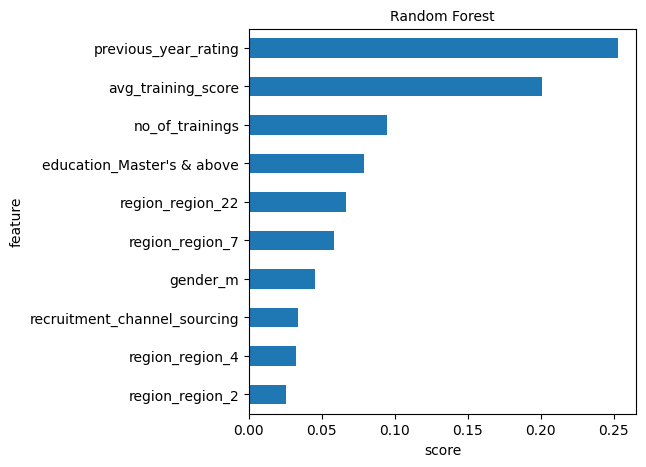

In [ ]:
show_feature_importance(model_rf, 'Random Forest')

In [ ]:
print('Shape of df_train :', df_train.shape)
print('Shape of df_test :', df_test.shape)

Shape of df_train : (54808, 54)
Shape of df_test : (20819, 52)


In [ ]:
simulation_features = X_smote.columns

In [ ]:
# Create Simulation Function

def simulation(feature):
    # Define TP FN FP TN var
    tp, fn, fp, tn = cf_matrix.flatten()

    # Create Simulation Data
    df_promoted = df_train[df_train.is_promoted == 1][simulation_features]
    df_not_promoted = df_train[df_train.is_promoted == 0][simulation_features]

    cr_list = []

    # Create Improvement Experiments
    experiments = np.arange(-1,1.05,0.05)
    experiments[20] = 0

    for i in experiments:
        df_simulation = pd.concat([df_promoted.sample(int(np.ceil(0.1*df_promoted.shape[0])), random_state=123), df_not_promoted.sample(int(np.ceil(0.1*df_not_promoted.shape[0])), random_state=123)]).reset_index(drop=True)
        df_simulation[feature] = df_simulation[feature]*(1+i)


        # Predict Simulation Values
        simulation_pred = model_rf.predict(df_simulation)

        # Adjust Predicted Value to Actual Value
        simulation_pred_pos = simulation_pred[simulation_pred==0]
        simulation_pred_pos[:(int(np.ceil((fp/(fp+tp))*(simulation_pred[simulation_pred==0].size))))] = 1
        simulation_pred_pos
        simulation_pred_neg = simulation_pred[simulation_pred==1]
        simulation_pred_neg[:(int(np.ceil((fn/(fn+tn))*(simulation_pred[simulation_pred==1].size))))] = 0
        simulation_pred_neg
        simulation_pred = np.concatenate((simulation_pred_neg, simulation_pred_pos))

        # Calculate Simulation Conversion Rate
        cr = simulation_pred[simulation_pred==1].size/simulation_pred.size
        cr_list.append(cr)

    # Create CR Plot
    # print(cr_list)
    plt.plot(experiments, cr_list, marker='o', linewidth=1)
    plt.ylabel('Promotion Rate')
    plt.xlabel(str(feature) + ' Increased')
    plt.title('Promotion Rate Increased by ' + str(feature))
    plt.axvline(linewidth=1, color='r', label = 'Current Condition')
    plt.legend()
    plt.show()

## Sensitifity Analysis

### Previous Year Rating

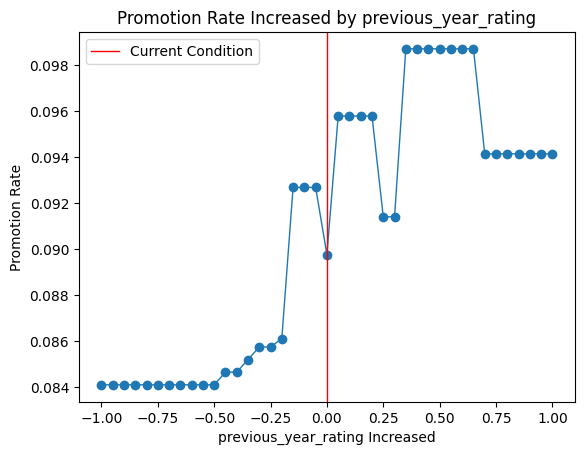

In [ ]:
simulation('previous_year_rating')

### Average Training Score

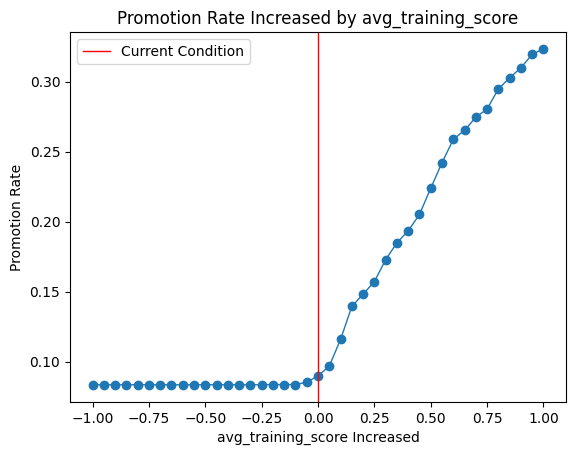

In [ ]:
simulation('avg_training_score')

### No of Training

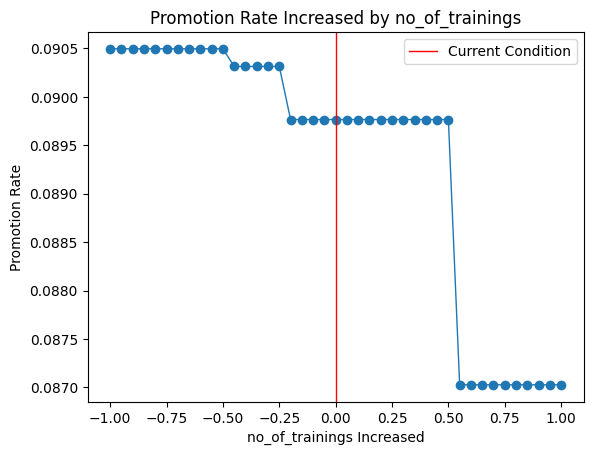

In [ ]:
simulation("no_of_trainings")

## Business Simulation

In [ ]:
print(df_train['avg_training_score'].describe())
print('\n')
print('Num of unique values :')
print(df_train['avg_training_score'].nunique())

count    54808.000000
mean        63.386750
std         13.371559
min         39.000000
25%         51.000000
50%         60.000000
75%         76.000000
max         99.000000
Name: avg_training_score, dtype: float64


Num of unique values :
61


In [ ]:
print(df_train['previous_year_rating'].describe())
print('\n')
print('Num of unique values :')
print(df_train['previous_year_rating'].nunique())
print('\n')
print('Unique Values')
print(df_train['previous_year_rating'].value_counts())

count    54808.000000
mean         3.304481
std          1.214770
min          1.000000
25%          3.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: previous_year_rating, dtype: float64


Num of unique values :
5


Unique Values
previous_year_rating
3.0    22742
5.0    11741
4.0     9877
1.0     6223
2.0     4225
Name: count, dtype: int64


In [ ]:
# Create Simulation Function

def simulation(feature, x):
    # Define TP FN FP TN var
    tp, fn, fp, tn = cf_matrix.flatten()

    # Create Simulation Data
    df_promoted = df_train[df_train.is_promoted == 1][simulation_features]
    df_not_promoted = df_train[df_train.is_promoted == 0][simulation_features]


    # Create Improvement Experiments
    experiments = np.arange(-1,1.05,0.05)
    experiments[20] = 0

    df_simulation = pd.concat([df_promoted.sample(int(np.ceil(0.3*df_promoted.shape[0])), random_state=123), df_not_promoted.sample(int(np.ceil(0.3*df_not_promoted.shape[0])), random_state=123)]).reset_index(drop=True)
    df_simulation[feature] = df_simulation[feature]*x


    # Predict Simulation Values
    simulation_pred = model_rf.predict(df_simulation)

    # Adjust Predicted Value to Actual Value
    simulation_pred_pos = simulation_pred[simulation_pred==0]
    simulation_pred_pos[:(int(np.ceil((fp/(fp+tp))*(simulation_pred[simulation_pred==0].size))))] = 1
    simulation_pred_pos
    simulation_pred_neg = simulation_pred[simulation_pred==1]
    simulation_pred_neg[:(int(np.ceil((fn/(fn+tn))*(simulation_pred[simulation_pred==1].size))))] = 0
    simulation_pred_neg
    simulation_pred = np.concatenate((simulation_pred_neg, simulation_pred_pos))

    # Calculate Simulation Promotion Rate
    new_pr = simulation_pred[simulation_pred==1].size/simulation_pred.size

    # Calculte existing promotion rate
    current_pr = df_train.is_promoted.value_counts()[1]/df_train.is_promoted.shape[0]

    # avg cost per hire (US Data) https://www.zippia.com/advice/cost-of-hiring-statistics-average-cost-per-hire/
    cph = 4425 # in dollar
    hiring_target_pct = 0.2 # max num recruiter can hire is 2% from remaining not promoted employees
    num_employees = 54808


    # hiring cost current condition
    current_num_employee_will_recruited = hiring_target_pct*(1-current_pr)*num_employees
    current_hc = current_num_employee_will_recruited*cph

    # hiring cost after recommendation
    new_num_employee_will_recruited = hiring_target_pct*(1-new_pr)*num_employees
    new_hc = new_num_employee_will_recruited*cph

    # percentage cost reduction
    pctg_cost_reduction = round((current_hc-new_hc)/new_hc*100,2)

    print(f'Current Average {feature} = {df_train[feature].median()}')
    print(f'Average {feature} after implementing recommendation = {round(df_train[feature].mean()*x)}')
    print('\n')
    print(f'Current Promotion Rate = {current_pr *100:.2f}%')
    print(f'Simulation Promotion Rate After Recommendation = {new_pr *100:.2f}%')
    print('Promotion Rate Increment = ', round((new_pr *100)-(current_pr *100),2))
    print('\n')
    print(f'Current Hiring Cost  = $ {round(current_hc)}')
    print(f'Hiring Cost After Implementing Recommendation = $ {round(new_hc)}')
    print(f'Percetage Hiring Cost Reduction = {pctg_cost_reduction}%')
    print('\n')
    print(f'Current Number of Talent Will Be Recruited = {round(current_num_employee_will_recruited)}')
    print(f'New Number of Talent Will Be Recruited = {round(new_num_employee_will_recruited)}')

In [ ]:
import joblib
import pandas as pd

# Load the trained model and the list of columns
try:
    final_model = joblib.load('promotion_model.joblib')
    model_columns = joblib.load('model_columns.joblib')
    print("Model and columns loaded successfully.")
except FileNotFoundError:
    print("Error: Model files not found. Please ensure 'promotion_model.joblib' and 'model_columns.joblib' are in the correct directory.")
    final_model = None
    model_columns = None

Model and columns loaded successfully.


In [ ]:
if final_model is not None and model_columns is not None:
    user_input = {}
    print("Please provide the following information for the employee:")

    for col in model_columns:
        # Add specific prompts for categorical features to guide the user
        if col in ['department', 'education', 'gender', 'recruitment_channel']:
            if col == 'department':
                value = input(f"Enter the employee's {col} (e.g., Sales & Marketing, Operations, Technology): ")
            elif col == 'education':
                 value = input(f"Enter the employee's {col} (e.g., Bachelor's, Master's & above, Below Secondary): ")
            elif col == 'gender':
                value = input(f"Enter the employee's {col} (f or m): ")
            elif col == 'recruitment_channel':
                value = input(f"Enter the employee's {col} (other, sourcing, or referred): ")
        elif col == 'awards_won?':
             value = input(f"Did the employee win awards? (0 for No, 1 for Yes): ")
        else:
            value = input(f"Enter the employee's {col}: ")

        user_input[col] = [value]

    # Convert user input to DataFrame
    input_df = pd.DataFrame(user_input)
    print("\nReceived input:")
    print(input_df)

else:
    print("Model or columns not loaded. Cannot proceed with getting input.")

Please provide the following information for the employee:
Enter the employee's department (e.g., Sales & Marketing, Operations, Technology): operation
Enter the employee's education (e.g., Bachelor's, Master's & above, Below Secondary): Masters
Enter the employee's gender (f or m): m
Enter the employee's recruitment_channel (other, sourcing, or referred): referred
Enter the employee's no_of_trainings: 5
Enter the employee's age: 21
Enter the employee's previous_year_rating: 8
Enter the employee's length_of_service: 2
Did the employee win awards? (0 for No, 1 for Yes): 0
Enter the employee's avg_training_score: 7

Received input:
  department education gender recruitment_channel no_of_trainings age  \
0  operation   Masters      m            referred               5  21   

  previous_year_rating length_of_service awards_won? avg_training_score  
0                    8                 2           0                  7  


In [ ]:
if final_model is not None and model_columns is not None:
    # Preprocess user input
    # Convert categorical features to the same encoded format as training data
    # This requires knowing the original categories and their mapping.
    # Since we saved the column names, we can use them to ensure correct encoding.

    # Create a dictionary to map column names to their dtypes in the original training data
    # This is a simplification; a more robust approach would save the encoders or the processed training data structure
    original_dtypes = {
        'department': 'object', 'education': 'object', 'gender': 'object', 'recruitment_channel': 'object',
        'no_of_trainings': 'int64', 'age': 'int64', 'previous_year_rating': 'float64',
        'length_of_service': 'int64', 'awards_won?': 'int64', 'avg_training_score': 'int64'
    }

    # Convert input data to appropriate types
    for col, dtype in original_dtypes.items():
      if col in input_df.columns:
        try:
            if dtype == 'int64':
                input_df[col] = pd.to_numeric(input_df[col], errors='coerce').astype('int64')
            elif dtype == 'float64':
                 input_df[col] = pd.to_numeric(input_df[col], errors='coerce').astype('float64')
            # No conversion needed for 'object' type yet, will handle with one-hot encoding
        except ValueError:
            print(f"Warning: Could not convert input for column '{col}' to {dtype}. This might affect the prediction.")
            input_df[col] = None # Set to None or handle appropriately


    # Apply one-hot encoding to categorical features
    # Need to ensure the new columns match the training data columns
    input_encoded = pd.get_dummies(input_df, drop_first=True)

    # Align columns - add missing columns with value 0 and ensure the order is the same
    input_aligned = input_encoded.reindex(columns=model_columns, fill_value=0)

    # Make prediction
    prediction = final_model.predict(input_aligned)

    # Display the prediction
    if prediction[0] == 1:
        print("\nPrediction: This employee is likely to be promoted.")
    else:
        print("\nPrediction: This employee is not likely to be promoted.")

else:
    print("Model or columns not loaded. Cannot make a prediction.")


Prediction: This employee is not likely to be promoted.


In [ ]:
# Create Simulation Function

def simulation(feature, variable, x, y):
    # Define TP FN FP TN var
    tp, fn, fp, tn = cf_matrix.flatten()

    # Create Simulation Data
    df_promoted = df_train[df_train.is_promoted == 1][simulation_features]
    df_not_promoted = df_train[df_train.is_promoted == 0][simulation_features]


    # Create Improvement Experiments
    experiments = np.arange(-1,1.05,0.05)
    experiments[20] = 0

    df_simulation = pd.concat([df_promoted.sample(int(np.ceil(0.3*df_promoted.shape[0])), random_state=123), df_not_promoted.sample(int(np.ceil(0.3*df_not_promoted.shape[0])), random_state=123)]).reset_index(drop=True)
    df_simulation[feature] = df_simulation[feature]*x
    df_simulation[variable] = df_simulation[variable]*y


    # Predict Simulation Values
    simulation_pred = model_rf.predict(df_simulation)

    # Adjust Predicted Value to Actual Value
    simulation_pred_pos = simulation_pred[simulation_pred==0]
    simulation_pred_pos[:(int(np.ceil((fp/(fp+tp))*(simulation_pred[simulation_pred==0].size))))] = 1
    simulation_pred_pos
    simulation_pred_neg = simulation_pred[simulation_pred==1]
    simulation_pred_neg[:(int(np.ceil((fn/(fn+tn))*(simulation_pred[simulation_pred==1].size))))] = 0
    simulation_pred_neg
    simulation_pred = np.concatenate((simulation_pred_neg, simulation_pred_pos))

    # Calculate Simulation Promotion Rate
    new_pr = simulation_pred[simulation_pred==1].size/simulation_pred.size

    # Calculte existing promotion rate
    current_pr = df_train.is_promoted.value_counts()[1]/df_train.is_promoted.shape[0]

    # avg cost per hire (US Data) https://www.zippia.com/advice/cost-of-hiring-statistics-average-cost-per-hire/
    cph = 4425 # in dollar
    hiring_target_pct = 0.2 # max num recruiter can hire is 2% from remaining not promoted employees
    num_employees = 54808


    # hiring cost current condition
    current_num_employee_will_recruited = hiring_target_pct*(1-current_pr)*num_employees
    current_hc = current_num_employee_will_recruited*cph

    # hiring cost after recommendation
    new_num_employee_will_recruited = hiring_target_pct*(1-new_pr)*num_employees
    new_hc = new_num_employee_will_recruited*cph

    # percentage cost reduction
    pctg_cost_reduction = round((current_hc-new_hc)/new_hc*100,2)

    print(f'Current Average {feature} = {df_train[feature].median()}')
    print(f'Average {feature} after implementing recommendation = {round(df_train[feature].mean()*x)}')
    print('\n')
    print(f'Current Promotion Rate = {current_pr *100:.2f}%')
    print(f'Simulation Promotion Rate After Recommendation = {new_pr *100:.2f}%')
    print('Promotion Rate Increment = ', round((new_pr *100)-(current_pr *100),2))
    print('\n')
    print(f'Current Hiring Cost  = $ {round(current_hc)}')
    print(f'Hiring Cost After Implementing Recommendation = $ {round(new_hc)}')
    print(f'Percetage Hiring Cost Reduction = {pctg_cost_reduction}%')
    print('\n')
    print(f'Current Number of Talent Will Be Recruited = {round(current_num_employee_will_recruited)}')
    print(f'New Number of Talent Will Be Recruited = {round(new_num_employee_will_recruited)}')

### Simulation 1 : Increase 10% of Average Training Score

In [ ]:
simulation('avg_training_score', 'avg_training_score', 1.10, 1.0)

Current Average avg_training_score = 60.0
Average avg_training_score after implementing recommendation = 70


Current Promotion Rate = 8.52%
Simulation Promotion Rate After Recommendation = 11.63%
Promotion Rate Increment =  3.12


Current Hiring Cost  = $ 44373900
Hiring Cost After Implementing Recommendation = $ 42861936
Percetage Hiring Cost Reduction = 3.53%


Current Number of Talent Will Be Recruited = 10028
New Number of Talent Will Be Recruited = 9686


### Simulation 2: Increase 20% of Average Training Score

In [ ]:
simulation('avg_training_score', 'avg_training_score', 1.20, 1.0)

Current Average avg_training_score = 60.0
Average avg_training_score after implementing recommendation = 76


Current Promotion Rate = 8.52%
Simulation Promotion Rate After Recommendation = 15.00%
Promotion Rate Increment =  6.49


Current Hiring Cost  = $ 44373900
Hiring Cost After Implementing Recommendation = $ 41227696
Percetage Hiring Cost Reduction = 7.63%


Current Number of Talent Will Be Recruited = 10028
New Number of Talent Will Be Recruited = 9317


### Simulation 3: Increase 30% of Average Training Score

In [ ]:
simulation('avg_training_score', 'avg_training_score', 1.30, 1.0)

Current Average avg_training_score = 60.0
Average avg_training_score after implementing recommendation = 82


Current Promotion Rate = 8.52%
Simulation Promotion Rate After Recommendation = 17.28%
Promotion Rate Increment =  8.76


Current Hiring Cost  = $ 44373900
Hiring Cost After Implementing Recommendation = $ 40124436
Percetage Hiring Cost Reduction = 10.59%


Current Number of Talent Will Be Recruited = 10028
New Number of Talent Will Be Recruited = 9068


### Simulation 4: Increase 10% of Previous Year Rating

In [ ]:
simulation('previous_year_rating', 'previous_year_rating', 1.10, 1.0)

Current Average previous_year_rating = 3.0
Average previous_year_rating after implementing recommendation = 4


Current Promotion Rate = 8.52%
Simulation Promotion Rate After Recommendation = 9.48%
Promotion Rate Increment =  0.96


Current Hiring Cost  = $ 44373900
Hiring Cost After Implementing Recommendation = $ 43909148
Percetage Hiring Cost Reduction = 1.06%


Current Number of Talent Will Be Recruited = 10028
New Number of Talent Will Be Recruited = 9923


### Combine Simulation 3 and Simulation 4 (1)

Using 30% increment of `Avg Training Score` and 10% Increment of `Previous Year Rating`

In [ ]:
simulation('avg_training_score', 'previous_year_rating', 1.30, 1.10)

Current Average avg_training_score = 60.0
Average avg_training_score after implementing recommendation = 82


Current Promotion Rate = 8.52%
Simulation Promotion Rate After Recommendation = 22.81%
Promotion Rate Increment =  14.29


Current Hiring Cost  = $ 44373900
Hiring Cost After Implementing Recommendation = $ 37442984
Percetage Hiring Cost Reduction = 18.51%


Current Number of Talent Will Be Recruited = 10028
New Number of Talent Will Be Recruited = 8462


### Combine Simulation 2 and Simulation 4 (2)

Using 20% increment of `Avg Training Score` and 10% Increment of `Previous Year Rating`

In [ ]:
simulation('avg_training_score', 'previous_year_rating', 1.20, 1.10)

Current Average avg_training_score = 60.0
Average avg_training_score after implementing recommendation = 76


Current Promotion Rate = 8.52%
Simulation Promotion Rate After Recommendation = 19.35%
Promotion Rate Increment =  10.83


Current Hiring Cost  = $ 44373900
Hiring Cost After Implementing Recommendation = $ 39121472
Percetage Hiring Cost Reduction = 13.43%


Current Number of Talent Will Be Recruited = 10028
New Number of Talent Will Be Recruited = 8841


### Combine Simulation 1 and Simulation 4 (3)

Using 10% increment of `Avg Training Score` and 10% Increment of `Previous Year Rating`

In [ ]:
simulation('avg_training_score', 'previous_year_rating', 1.10, 1.10)

Current Average avg_training_score = 60.0
Average avg_training_score after implementing recommendation = 70


Current Promotion Rate = 8.52%
Simulation Promotion Rate After Recommendation = 14.33%
Promotion Rate Increment =  5.81


Current Hiring Cost  = $ 44373900
Hiring Cost After Implementing Recommendation = $ 41555134
Percetage Hiring Cost Reduction = 6.78%


Current Number of Talent Will Be Recruited = 10028
New Number of Talent Will Be Recruited = 9391


In [ ]:
# --- save_model.py ---
# This script contains the logic from your notebook to train the model and save it.
# You should add the code from Step 2 below to a new cell at the end of your
# "Employee Promotion Prediction.ipynb" notebook and run it once.

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import joblib

# --- Step 1: Data Loading and Preprocessing (from your notebook) ---
# This assumes you have a 'train.csv' file in the same directory.
try:
    df = pd.read_csv('train.csv')
except FileNotFoundError:
    print("Error: 'train.csv' not found. Please place the dataset in the same directory.")
    exit()

# Dropping unnecessary columns and handling missing values
df = df.drop(['employee_id', 'region'], axis=1)
df['education'] = df['education'].fillna("Bachelor's")
df['previous_year_rating'] = df['previous_year_rating'].fillna(df['previous_year_rating'].mean())

# Encoding categorical features into numbers
le = LabelEncoder()
categorical_cols = ['department', 'education', 'gender', 'recruitment_channel']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# --- Step 2: Train and Save the Final Model ---
print("Starting final model training...")

# Prepare the data for training
X = df.drop('is_promoted', axis=1)
y = df['is_promoted']

# Train the Random Forest Model on the entire dataset
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X, y)

print("Model training complete.")

# Save the trained model to a file so our web app can use it
joblib.dump(final_model, 'promotion_model.joblib')

# Save the column order, which is crucial for making predictions
joblib.dump(list(X.columns), 'model_columns.joblib')

print("Model and columns saved successfully!")
print("You can now run the 'app.py' web server.")



Starting final model training...
Model training complete.
Model and columns saved successfully!
You can now run the 'app.py' web server.


In [ ]:
import pickle

# Assume 'model' is your trained machine learning model
# For example, a scikit-learn model:
# from sklearn.linear_model import LogisticRegression
# model = LogisticRegression()
# model.fit(X_train, y_train)

# Define the filename for your saved model
filename = 'cat.pkl'

# Open the file in binary write mode ('wb')
with open(filename, 'wb') as file:
    # Use pickle.dump() to serialize the model and save it to the file
    pickle.dump(cat, file)

print(f"Model saved successfully as {filename}")

Model saved successfully as cat.pkl
